The purpose of this code is to quantify the nuclei, the size and number of synuclein inclusions, and the lysosomal surface area in the lysotracker experiments.

Import Libraries

In [154]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import remove_small_objects, disk, binary_closing
from scipy.ndimage import zoom
from skimage.measure import label, regionprops
from skimage import exposure
from czifile import imread
from cellpose import models, io, plot 
model = models.Cellpose(model_type='cyto')

Define Sub Functions

In [155]:
def display_image(image, path, number):
    """Display the image."""
    plt.imshow(image)
    plt.axis('off')
    plt.title(path + " cell " + str(number))
    plt.show()

def image_name(image_path):
    """Extract the image name from the file path."""
    return os.path.splitext(os.path.basename(image_path))[0]

def extract_image_paths(folder):
    """Extract all image file paths from the specified folder."""
    return [os.path.join(folder, f) for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]

def read_image(image_path):
    """Read the LSM image from the specified path."""
    return imread(image_path)

def extract_channels(image):
    """Extract DAPI, green, and red channels from the image."""
    return image[0], image[1], image[2]

def otsu_thresholding(channel, path):
    """Apply Otsu's thresholding and morphological closing to the channel."""
    threshold_value = threshold_otsu(channel)
    binary_image = channel > threshold_value
    closed_image = binary_closing(binary_image, disk(3))
    labeled_image = label(closed_image)
    return labeled_image

def calculate_surface_area(labeled_image, channel):
    """Calculate the total surface area for labeled regions."""
    props = regionprops(labeled_image, channel)
    return sum(prop.area for prop in props)

def preprocess_dapi_channel(dapi_channel, path):
    """Preprocess the DAPI channel for nuclei quantification."""
    blurred_dapi = gaussian(dapi_channel, sigma=2)
    #masks, flows, styles, diams = model.eval(blurred_dapi, channels= [3,0])
    #labeled_cells = label(masks)
    #display_image(labeled_cells, path)
    return blurred_dapi

def count_nuclei(labeled_image):
    """Count the number of nuclei in the labeled image."""
    return len(np.unique(labeled_image)) - 1

def preprocess_red_green_channel(green_channel, red_channel, path):
    """Preprocess the green channel for inclusion quantification."""
    confocal_img = exposure.adjust_sigmoid(green_channel, cutoff=0.25)
    confocal_img = (confocal_img - confocal_img.min()) / (confocal_img.max() - confocal_img.min())
    individual_inclusions_per_cell = []
    surface_areas = []

    cell_inclusion_details = []  # To store cell number and inclusion count
    masks, flows, styles, diams = model.eval(confocal_img, diameter=150, channels=[3, 0])
    labeled_cells = label(masks)
    labeled_image_otsu = otsu_thresholding(red_channel, path)
    surface_area = calculate_surface_area(labeled_image_otsu, red_channel)
    surface_areas.append(surface_area)
    #display_image(labeled_cells, path, 0)
    filtered_cells = [cell for cell in regionprops(labeled_cells) if cell.area >= 100]
    for i, cell in enumerate(filtered_cells):

        mask = labeled_cells == cell.label


        applied_mask = gaussian(green_channel) * mask
        threshold_value = threshold_otsu(green_channel)
        threshold = 0.45
        #threshold2 = 0.4
        #threshold3 = 0.45
        #threshold3 = 0.45
        inclusions = applied_mask > threshold
        inclusions_labeled = label(inclusions)
        display_image(inclusions_labeled, path, i + 1)

        inclusion_size = []

        for region in regionprops(inclusions_labeled):  # Loop through each inclusion
            if region.area < 10:  # Filter out small inclusions
                continue
            inclusion_size.append(region.area)

        # If no inclusions, add a single row with 0 inclusions
        if not inclusion_size:
            cell_inclusion_details.append({
                'Filename': path,
                'Cell Number': i + 1,
                'Inclusion Number': None,  # No inclusion number
                'Inclusion Surface Area': 0,  # No inclusion surface area
                'Cytoplasm Surface Area': cell.area,
                'Lysosome Surface Area': surface_area,
                'Ratio of Lysosome to Cytoplasm': surface_area / cell.area,
            })
        else:
            # Add one row per inclusion
            for j, size in enumerate(inclusion_size):
                if size / cell.area > 0.7:  # Catch cases of poor segmentation
                    continue
                cell_inclusion_details.append({
                    'Filename': path,
                    'Cell Number': i + 1,
                    'Inclusion Number': j + 1,  # Inclusion number (1, 2, 3, etc.)
                    'Inclusion Surface Area': size,  # Surface area of this inclusion
                    'Cytoplasm Surface Area': cell.area,
                    'Lysosome Surface Area': surface_area,
                    'Ratio of Lysosome to Cytoplasm': surface_area / cell.area,
                })

    df_cell_summary = pd.DataFrame(cell_inclusion_details)
    return df_cell_summary

def threshold_inclusions(confocal_img, path):
    """Threshold the preprocessed green channel to segment inclusions."""
    binary_image = confocal_img > 0.95
    #display_image(binary_image, path)
    labeled_image = label(binary_image)
    return labeled_image

def measure_inclusion_sizes(labeled_image, confocal_img):
    """Measure the sizes of inclusions."""
    props = regionprops(labeled_image, confocal_img)
    sizes = [prop.area for prop in props]
    return [size for size in sizes if size > 10]

def add_to_dataframe(sizes_df_new, sizes, path):
    """Add sizes of inclusions to the DataFrame."""
    sizes_df_add = pd.DataFrame(sizes, columns=[f'image {path}'])
    if sizes_df_new is None:
        return sizes_df_add
    else:
        return pd.concat([sizes_df_new, sizes_df_add], axis=1)

def calculate_metrics(surface_areas, number_of_nuclei_list, mean_sizes_of_inclusions, sizes_df_new):
    """Calculate additional metrics and return the second DataFrame."""
    sizes_df_new_nuclei = sizes_df_new.transpose()
    number_of_inclusions = sizes_df_new_nuclei.count(axis=1)
    average_number_of_inclusions = number_of_inclusions / np.array(number_of_nuclei_list)
    surface_area_to_nuclei = [sa / n for sa, n in zip(surface_areas, number_of_nuclei_list)]

    return pd.DataFrame({
        "number_of_inclusions": number_of_inclusions,
        "Number_of_Nuclei": number_of_nuclei_list,
        "Average_Number_of_Inclusions_per_Cell": average_number_of_inclusions,
        "Surface_areas_lysosomes": surface_areas,
        "Surface_areas_to_nuclei": surface_area_to_nuclei,
        "mean_sizes_of_inclusions": mean_sizes_of_inclusions
    })

def save_to_excel(sizes_df_new, excel_2):
    """Save the DataFrames to Excel files."""
    excel_2.to_excel("SUMMARY.xlsx")

def sizes_of_all_inclusions(inclusions_size_list): 
    inclusions_df_array = []
    for df in inclusions_size_list:
        inclusions_df_array.extend(df.to_dict(orient='records'))
    return pd.DataFrame(inclusions_df_array)

Define Main Function

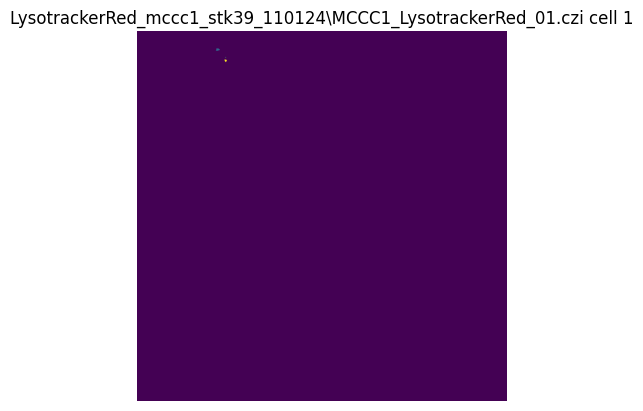

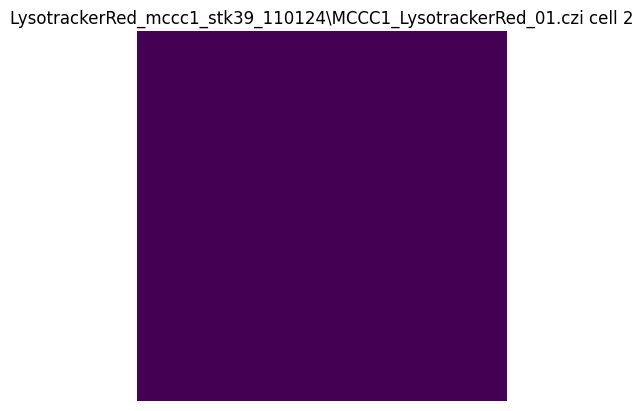

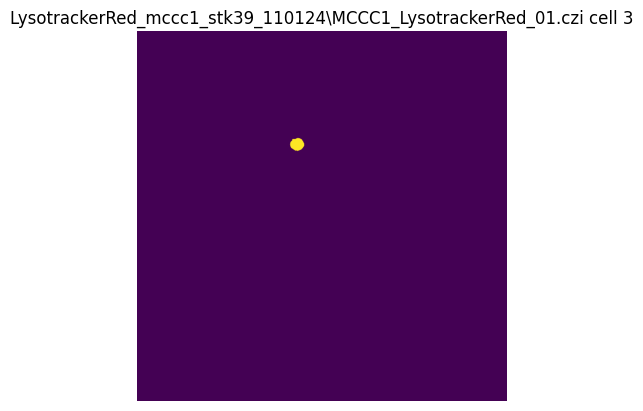

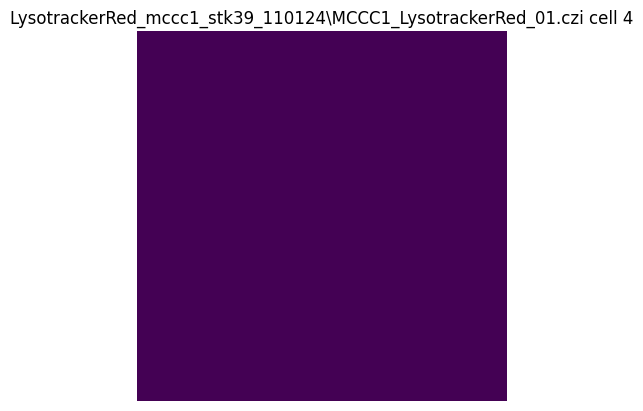

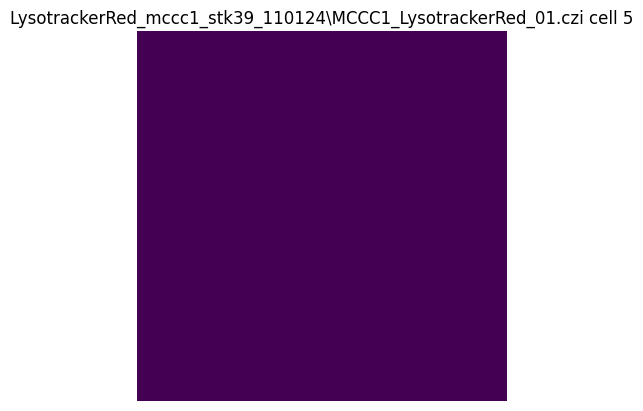

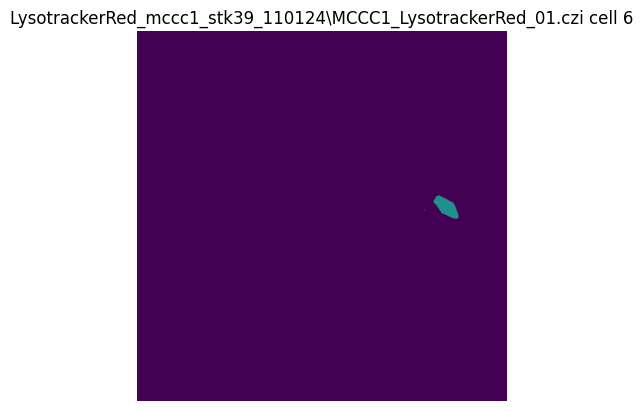

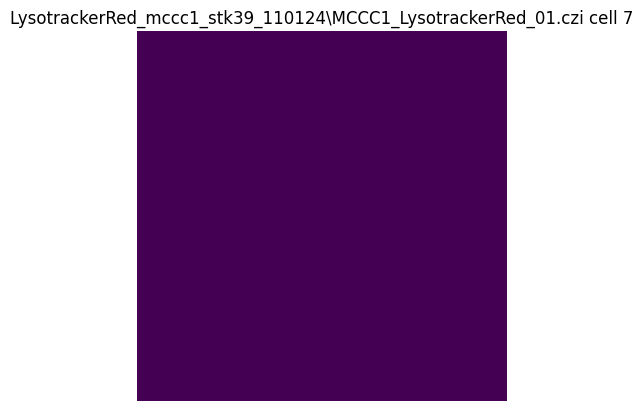

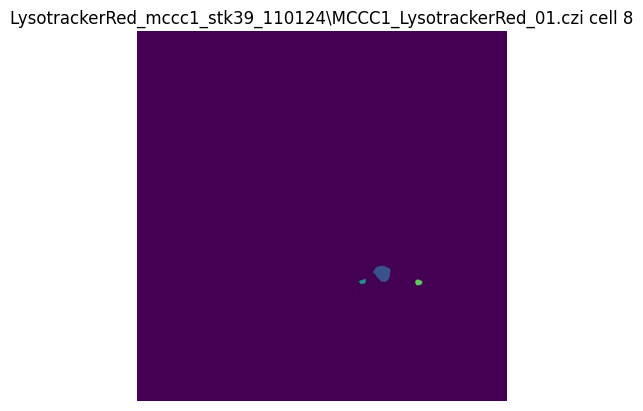

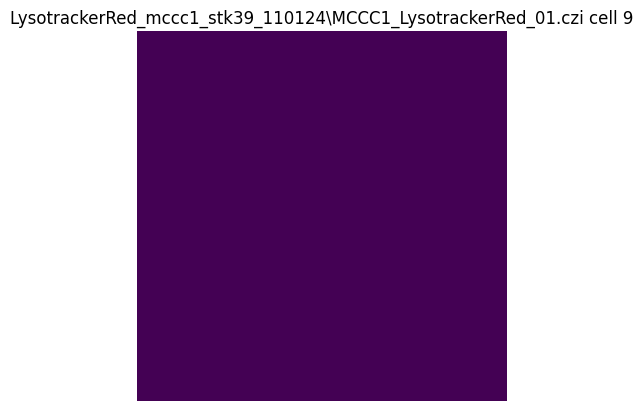

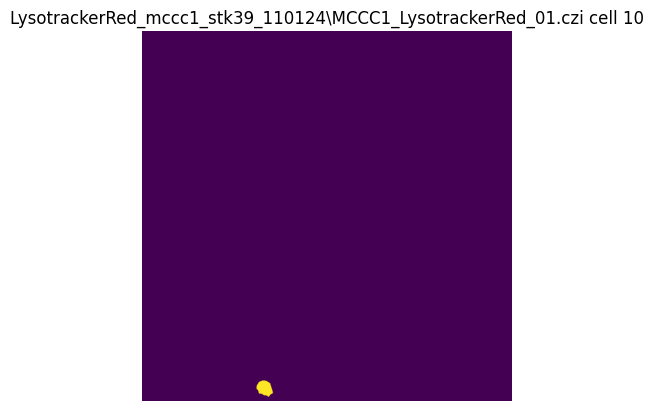

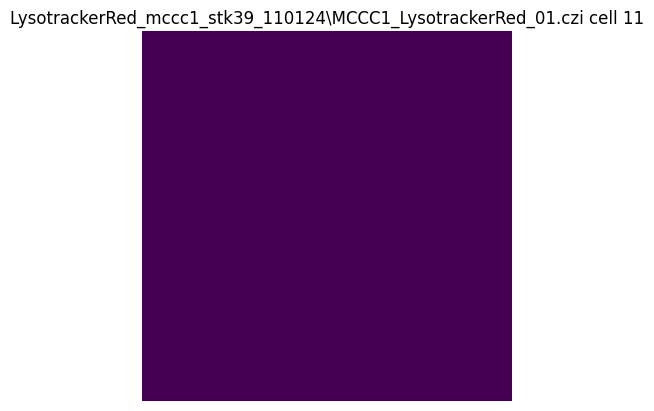

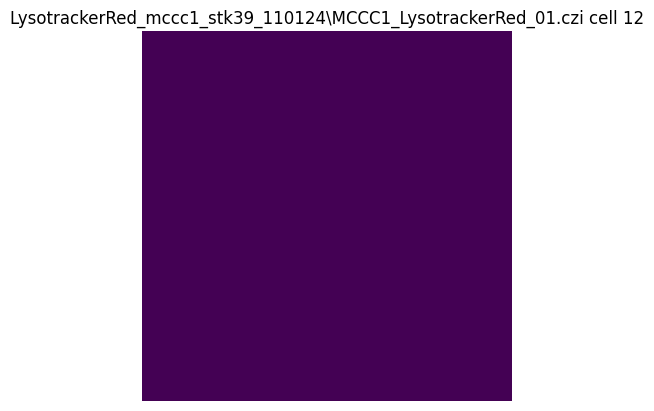

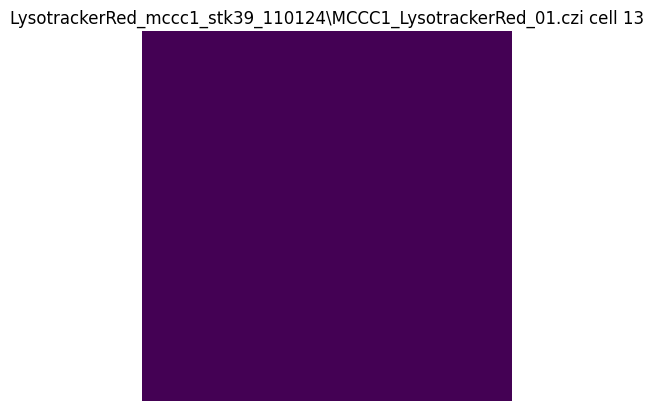

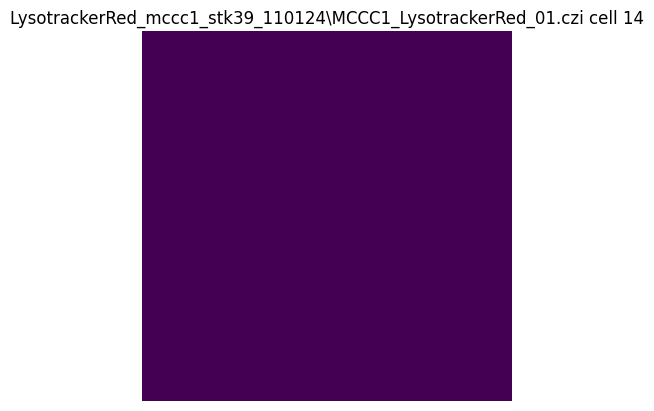

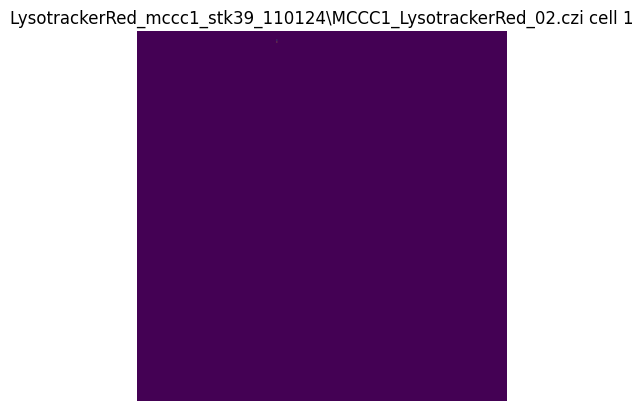

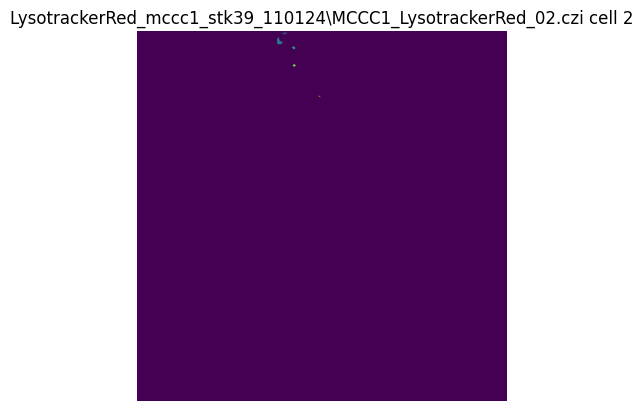

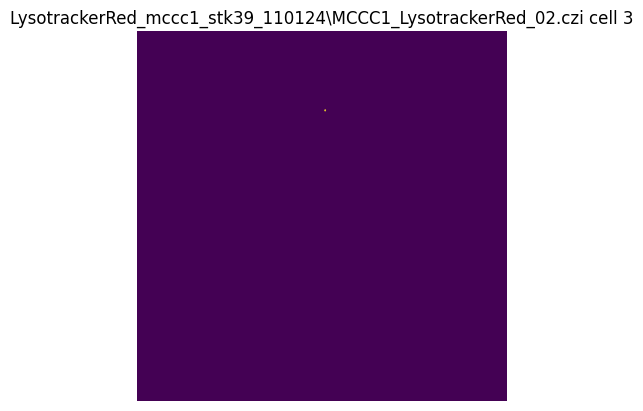

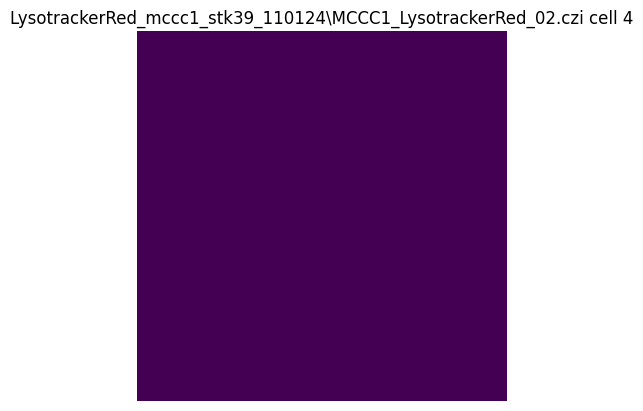

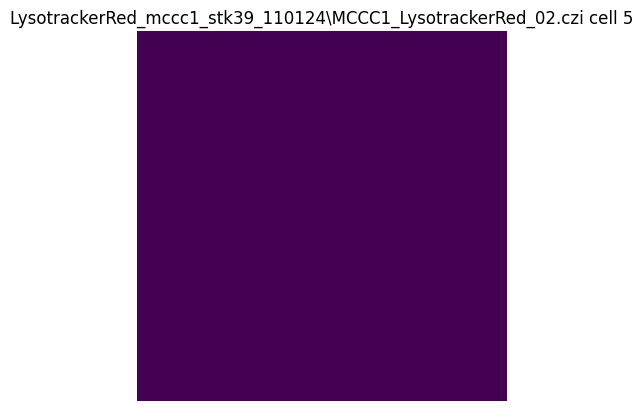

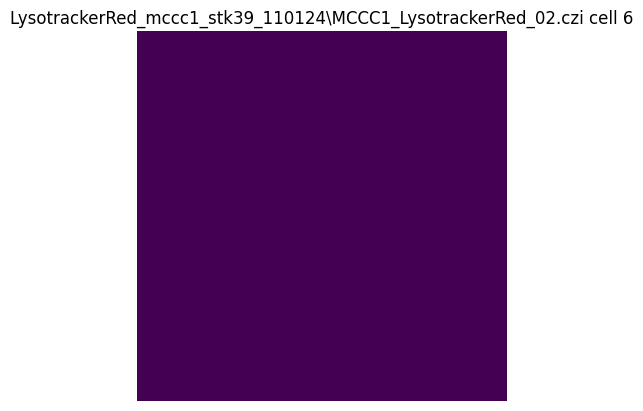

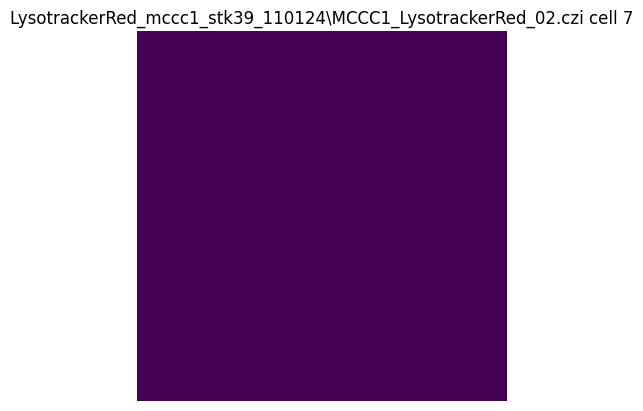

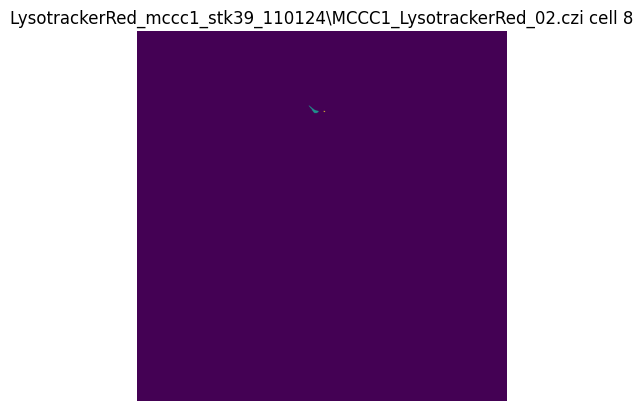

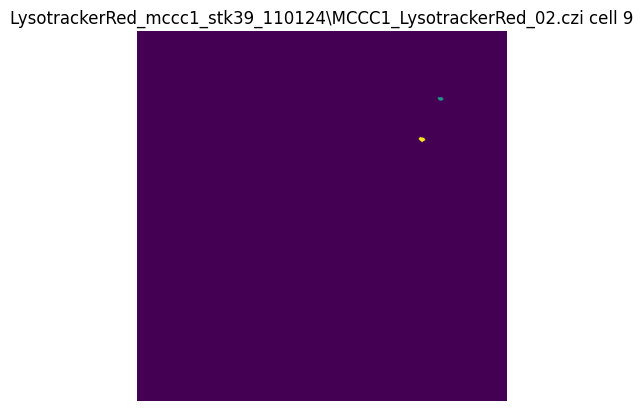

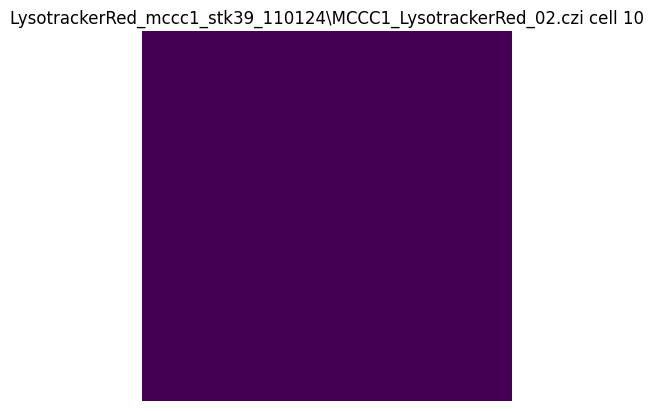

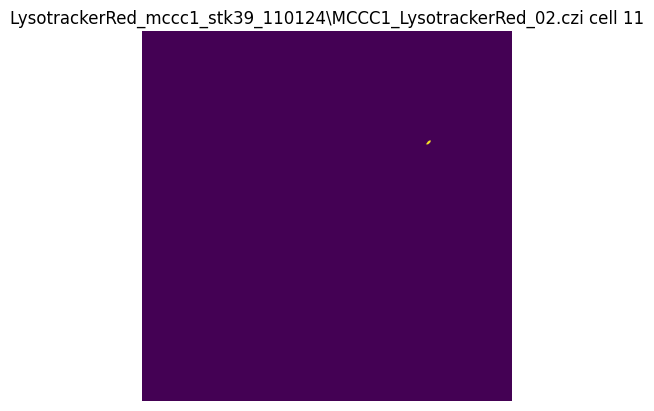

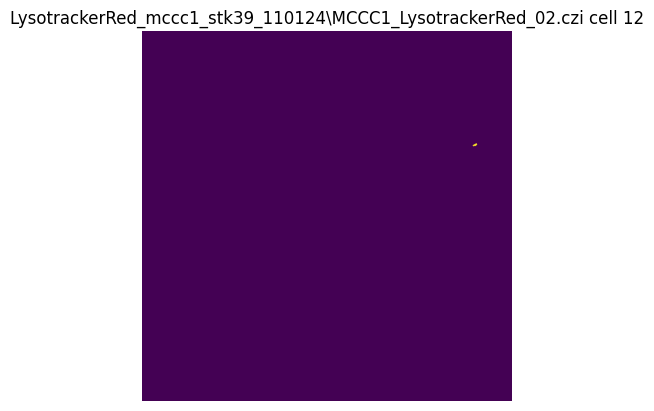

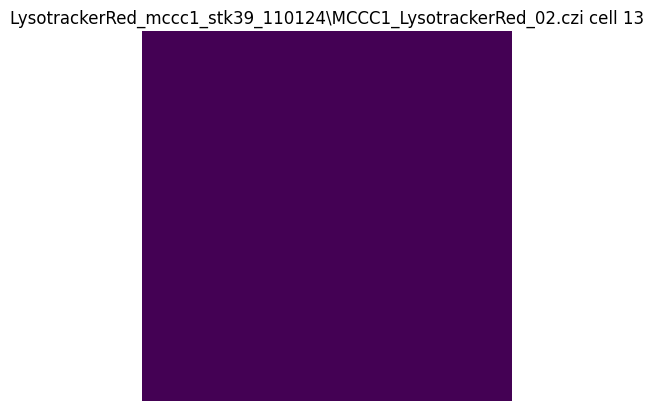

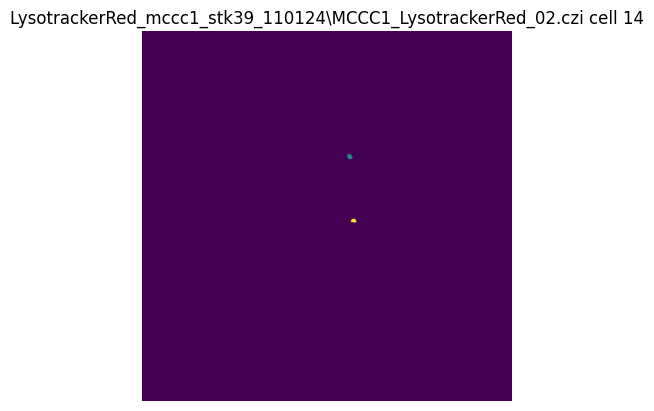

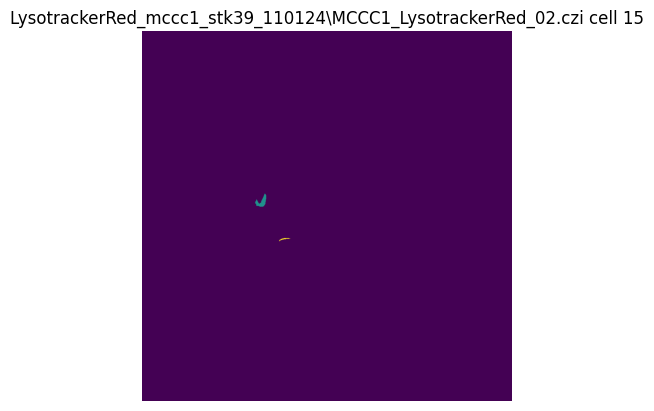

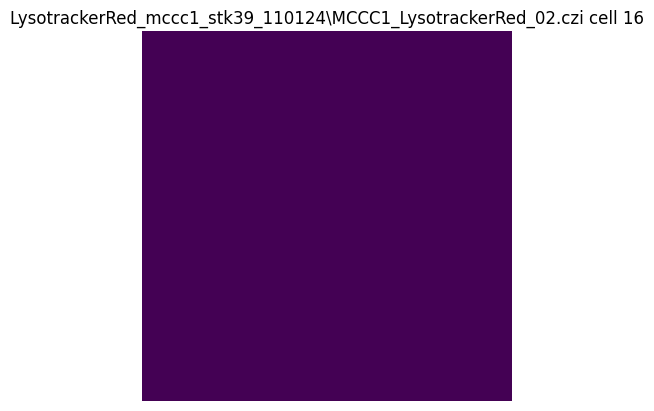

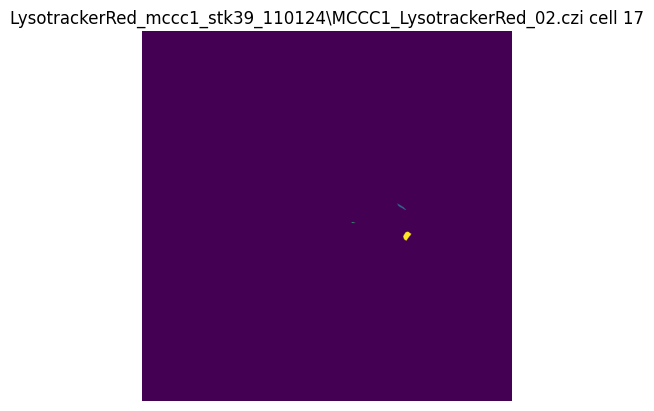

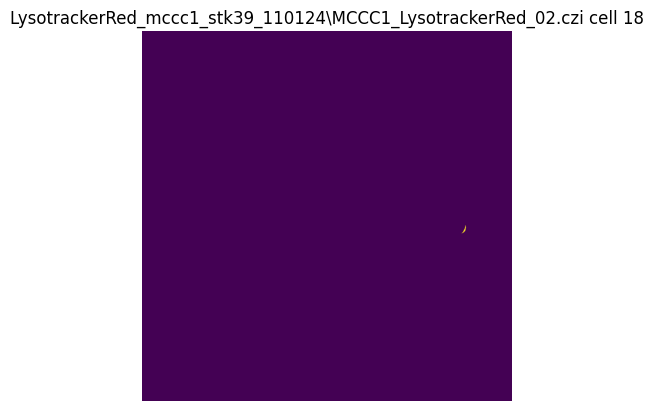

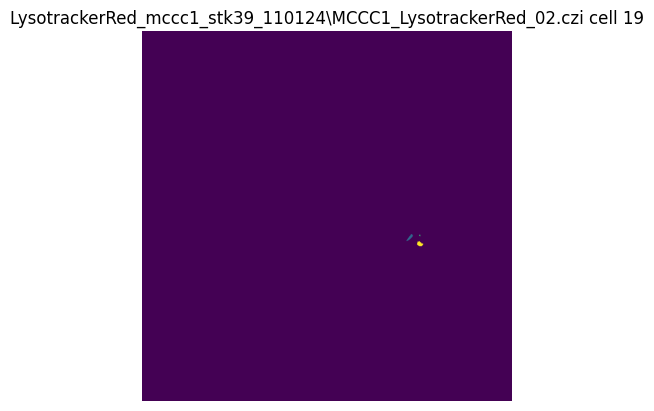

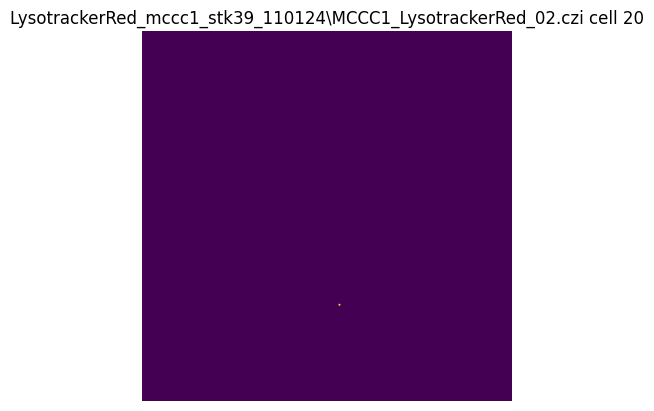

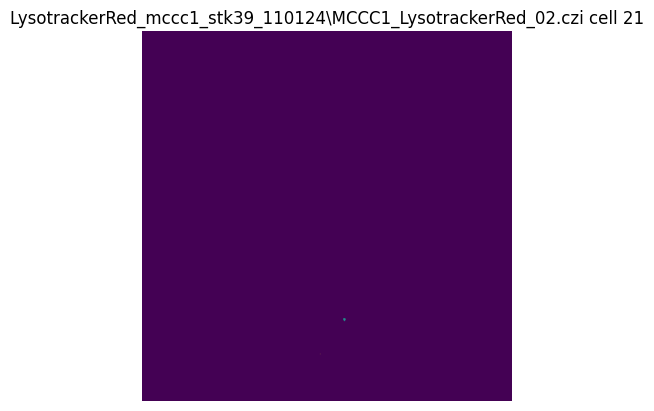

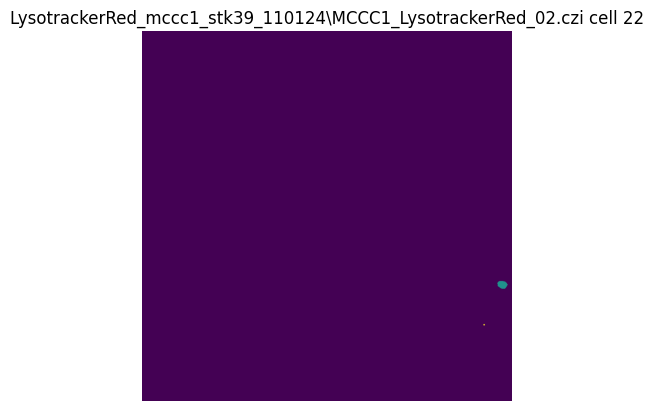

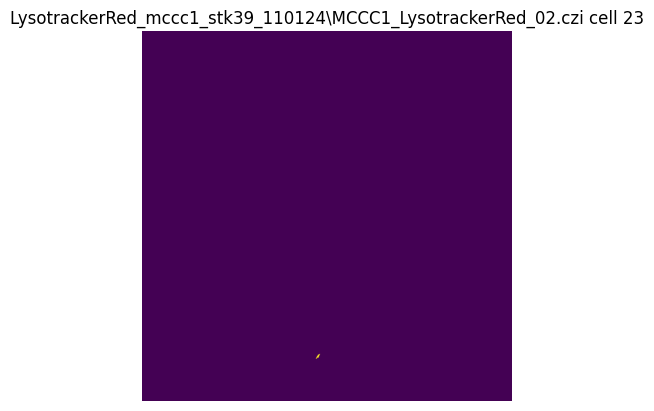

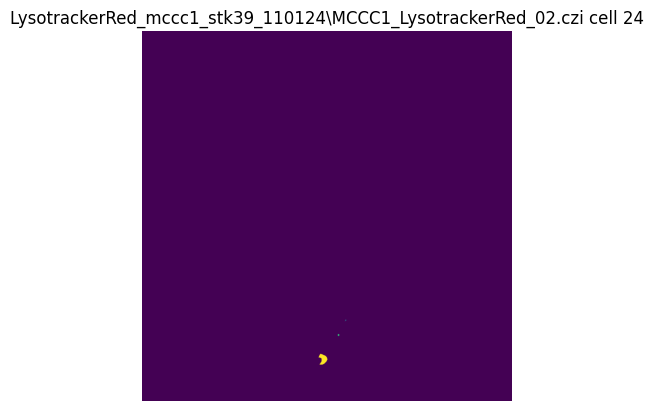

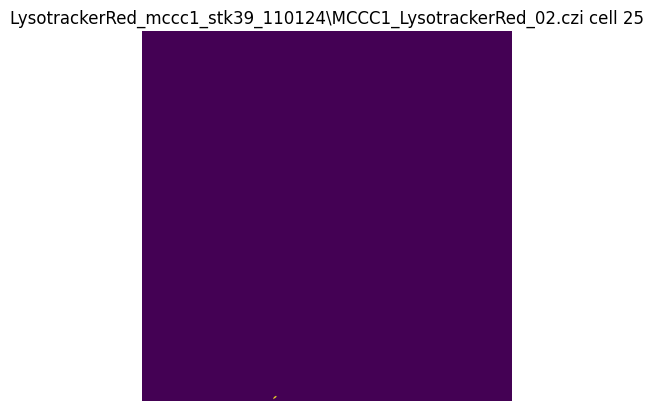

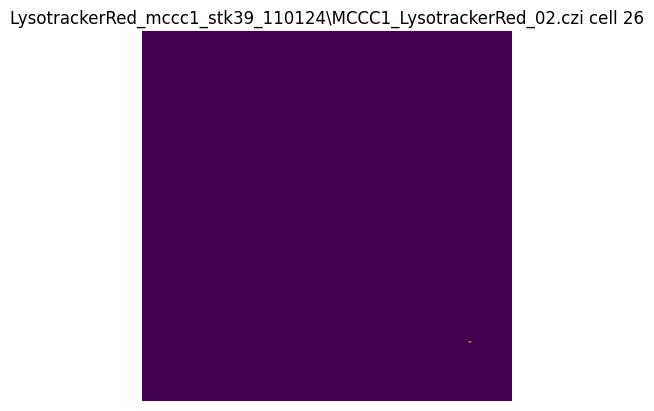

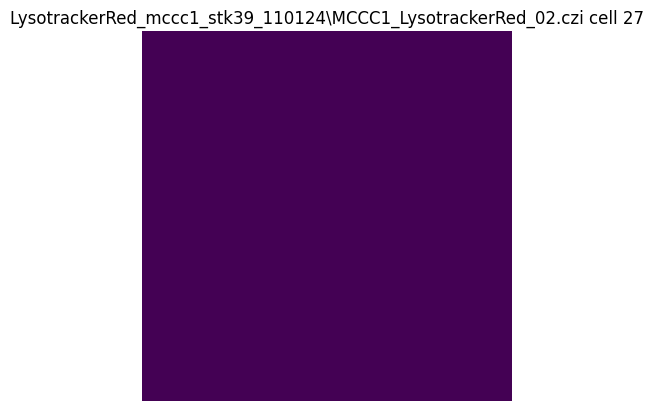

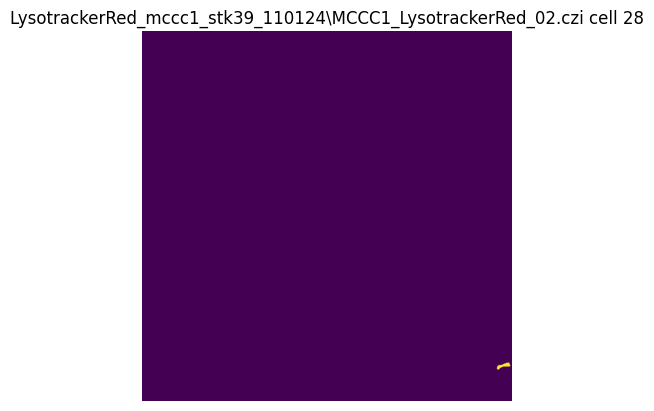

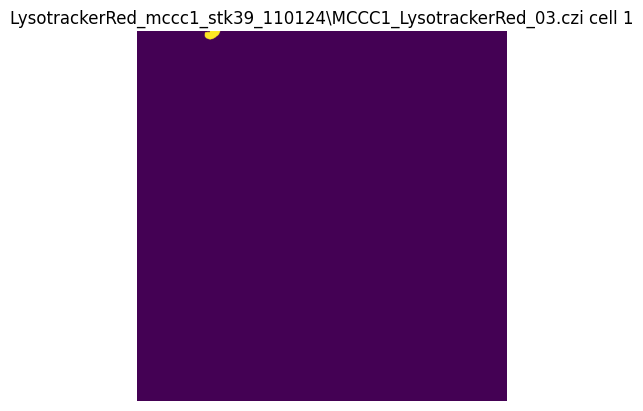

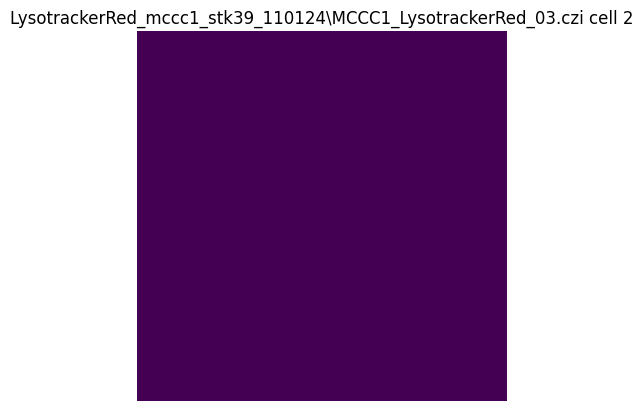

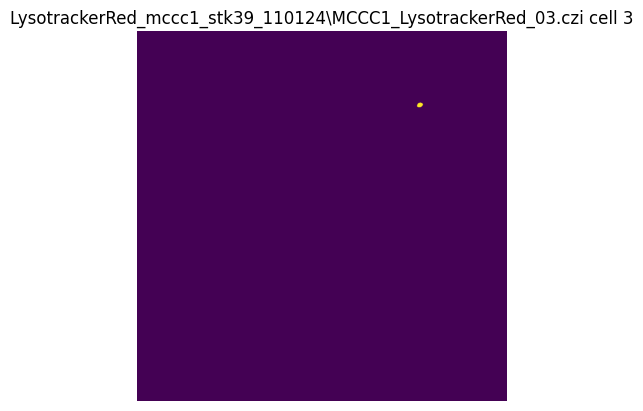

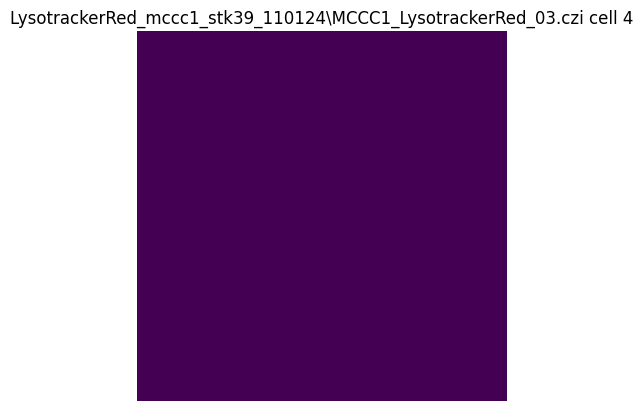

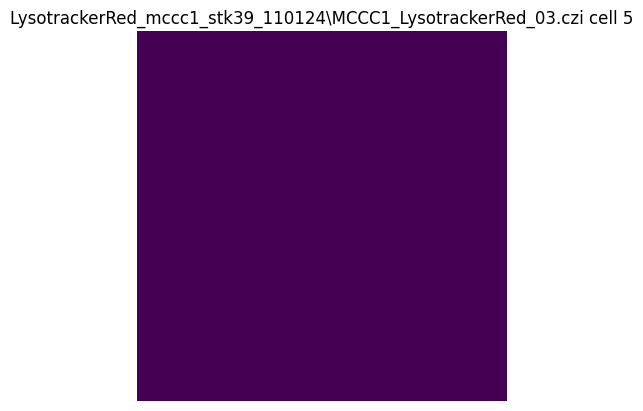

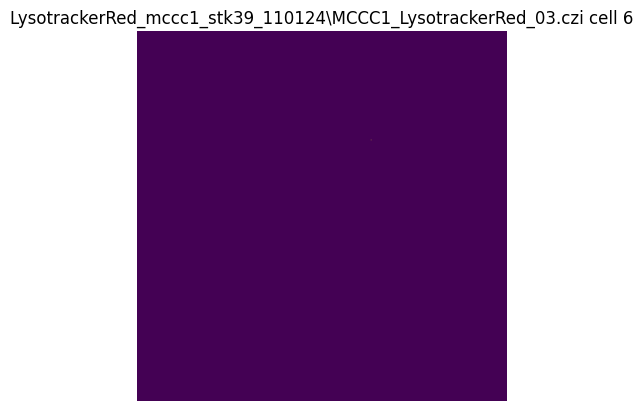

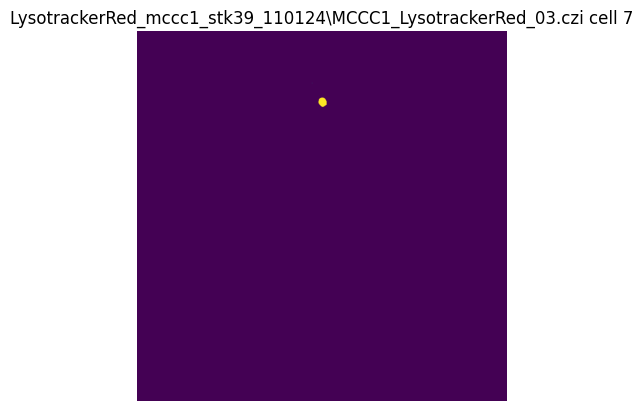

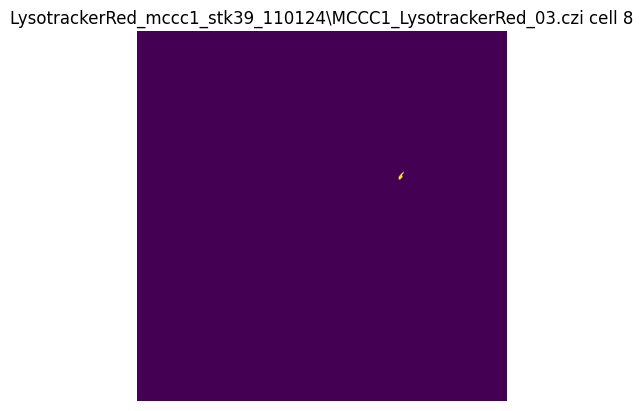

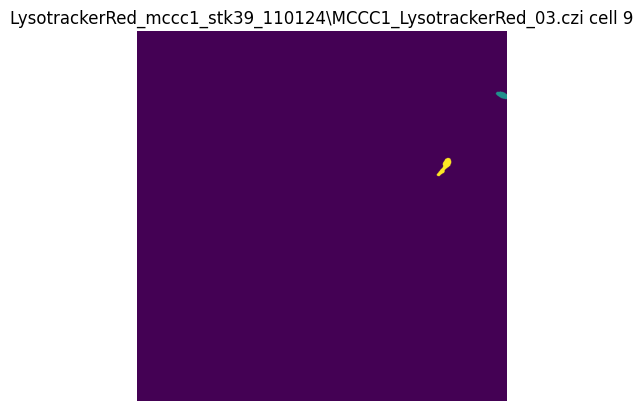

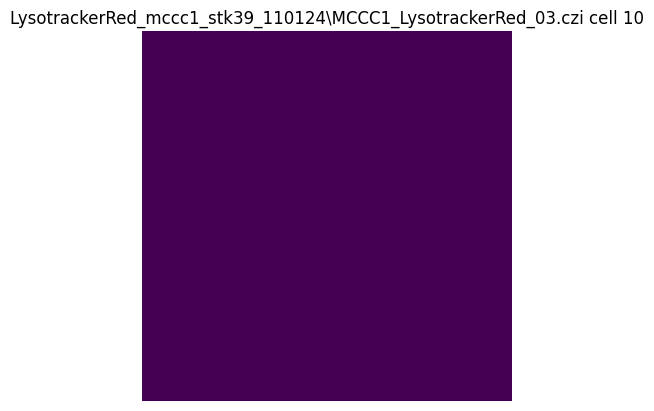

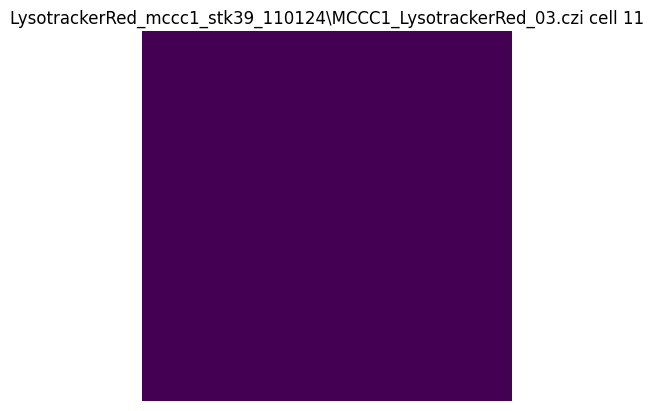

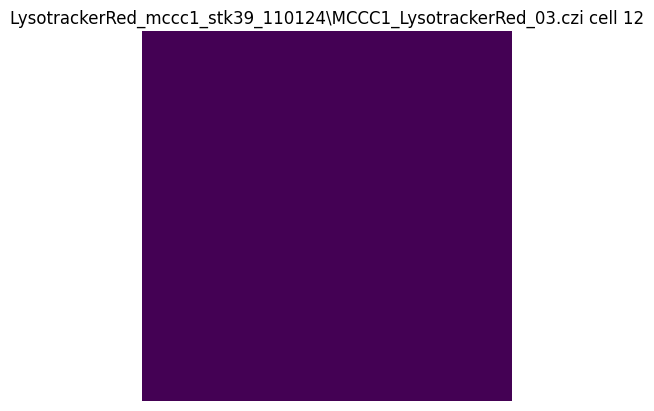

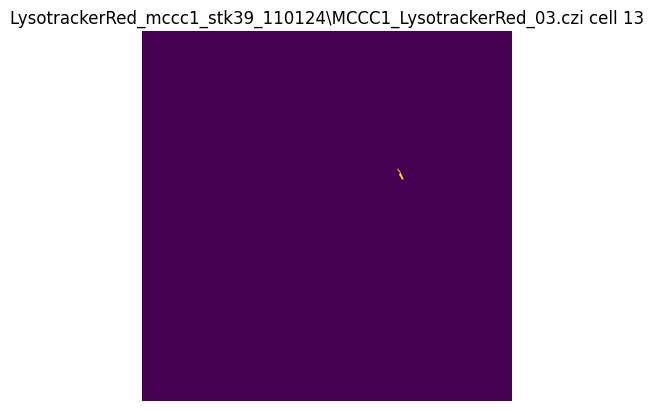

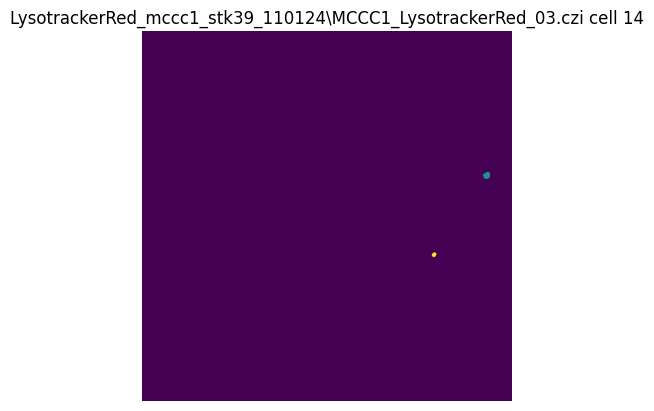

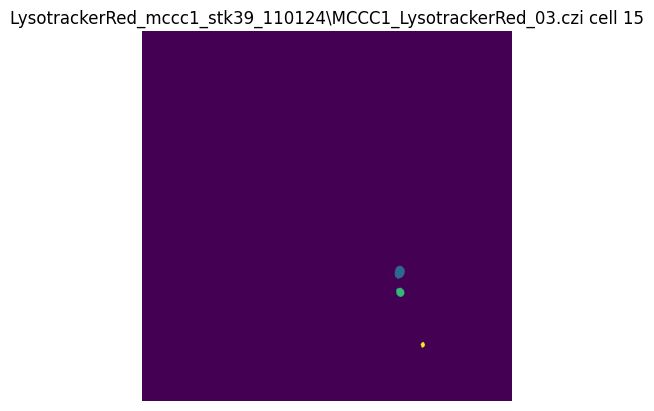

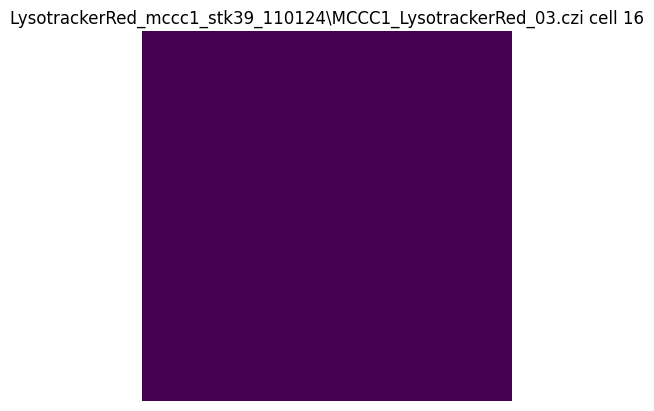

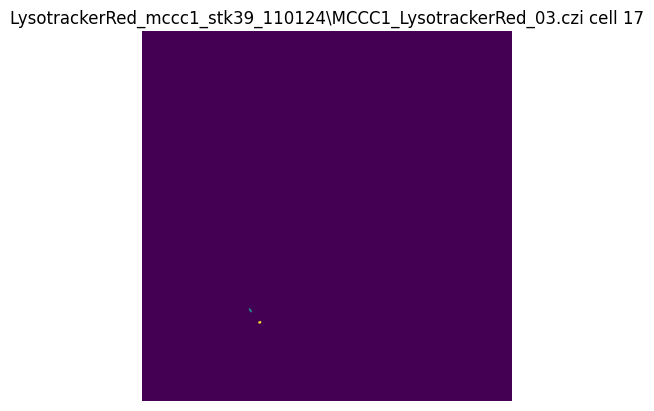

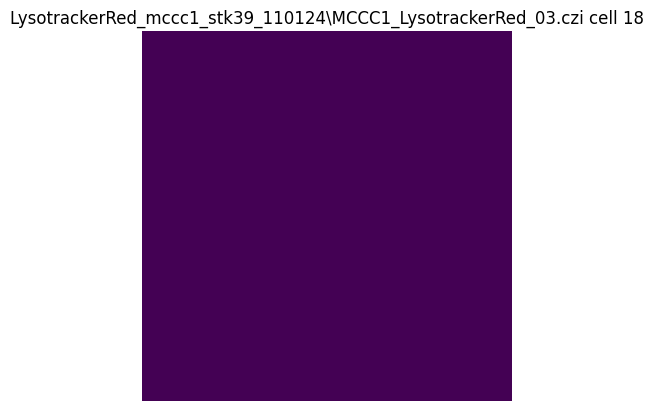

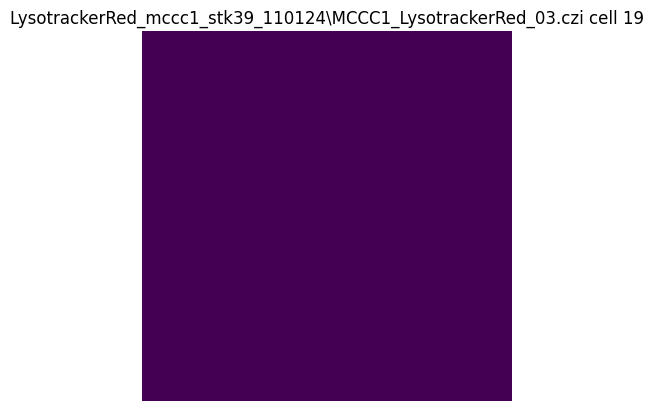

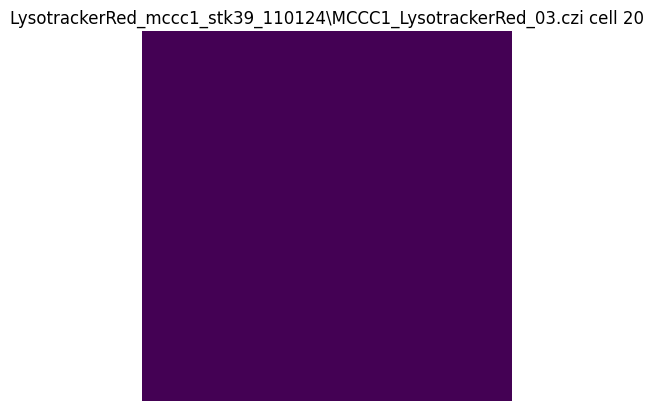

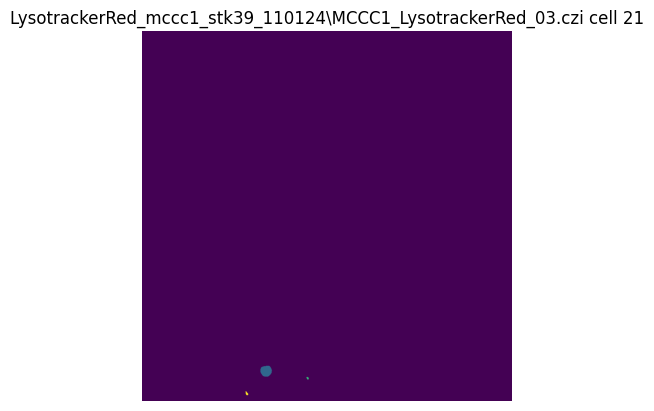

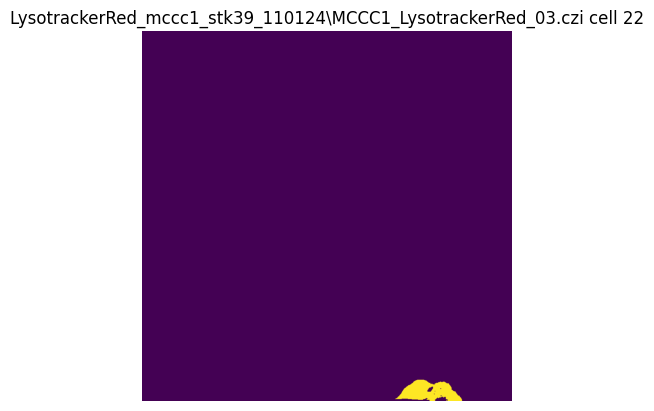

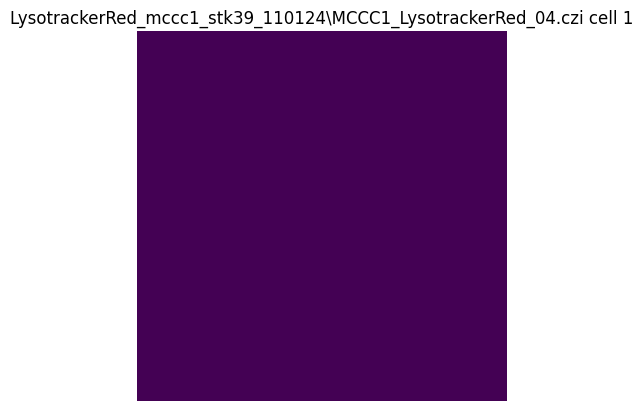

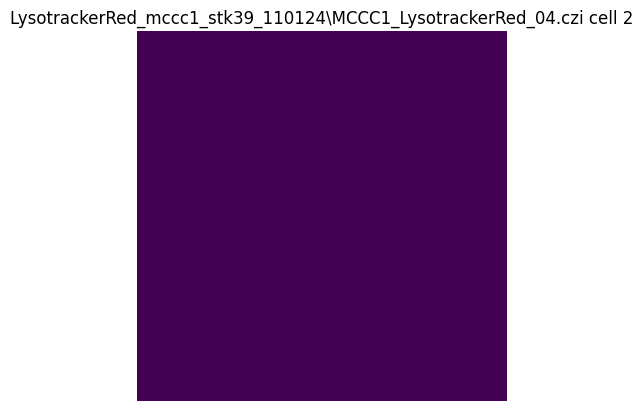

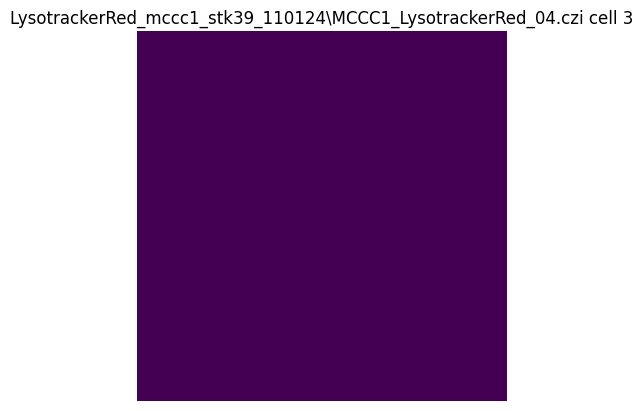

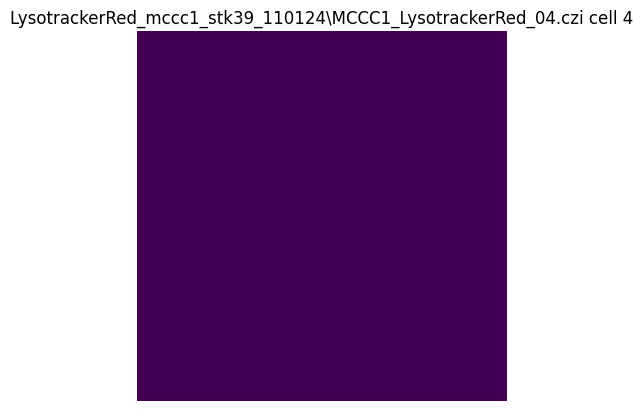

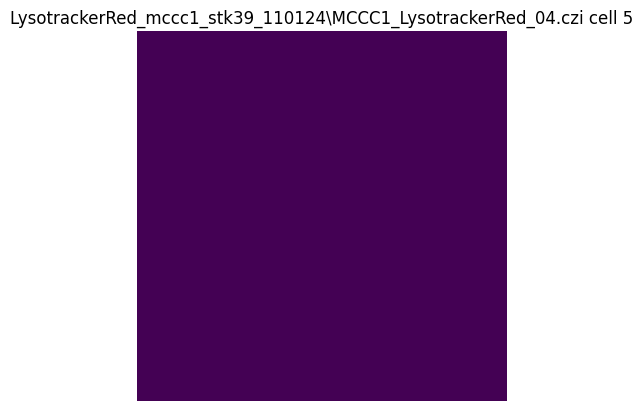

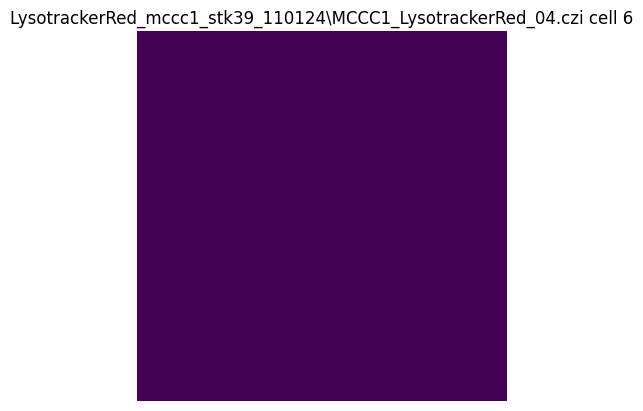

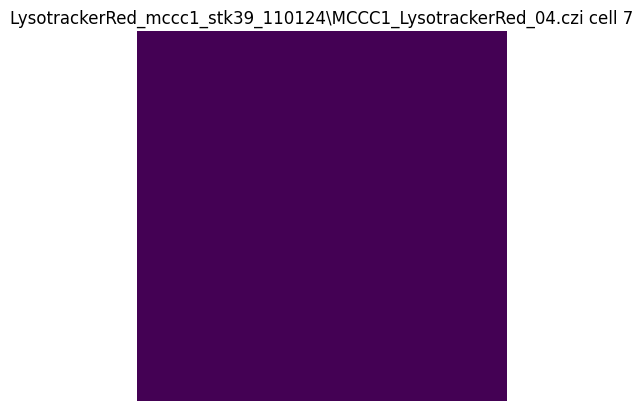

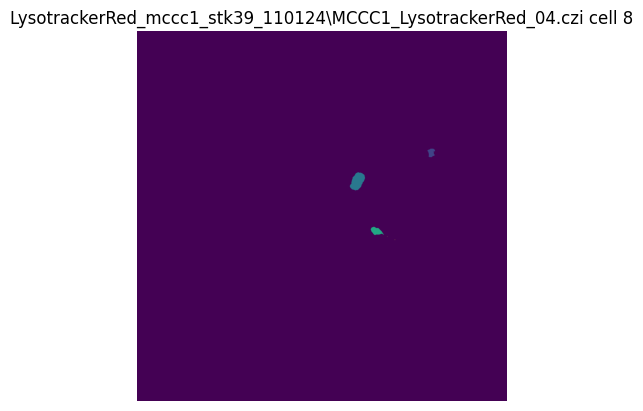

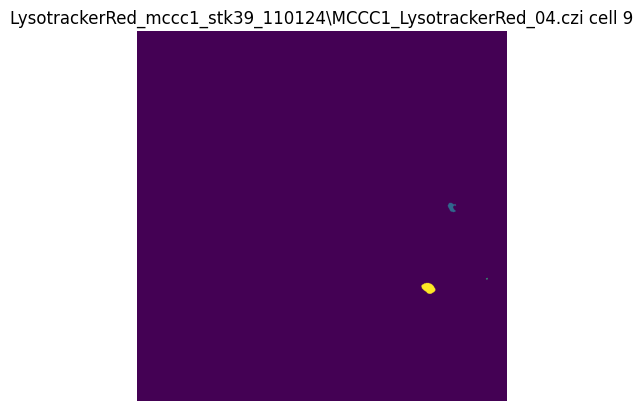

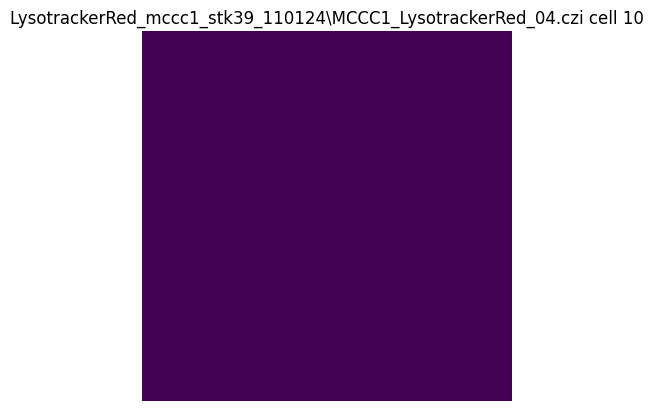

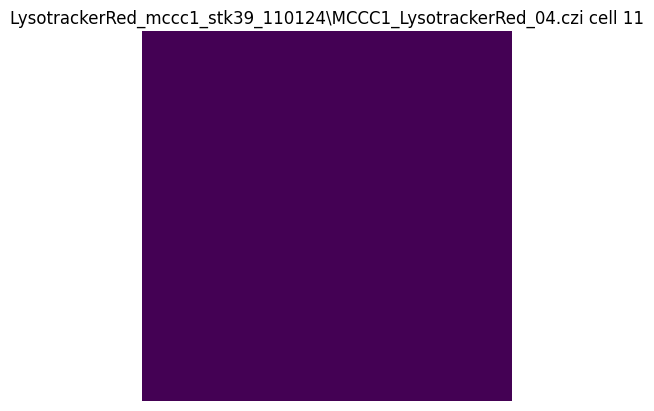

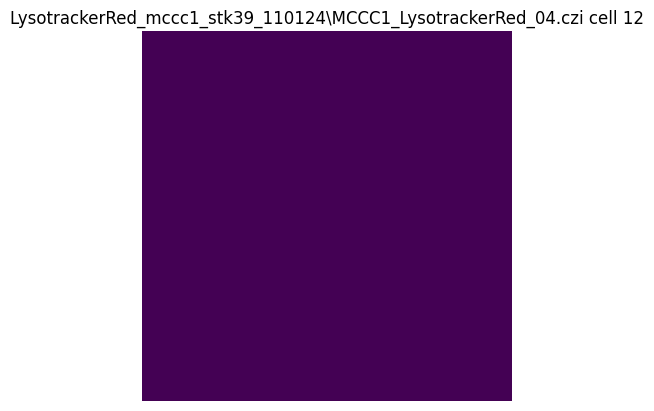

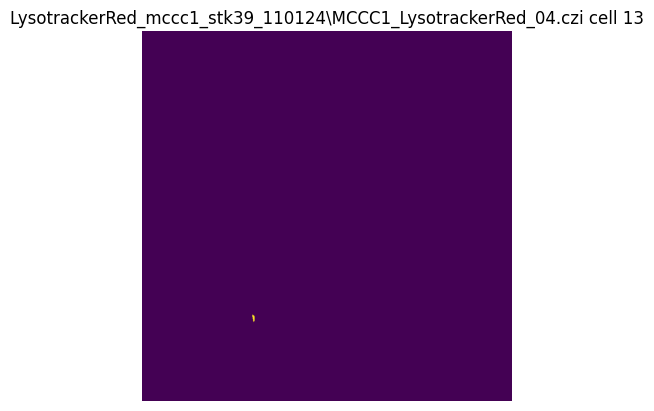

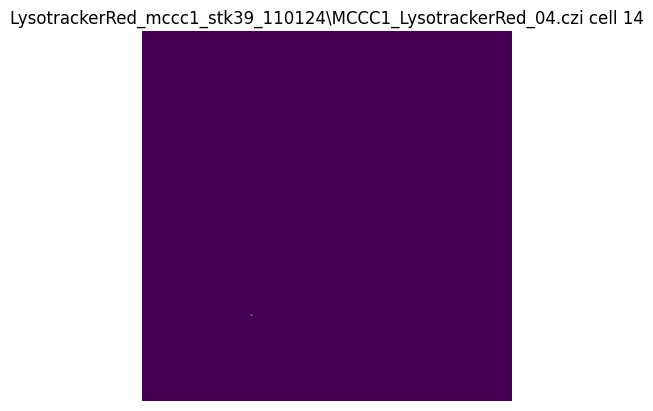

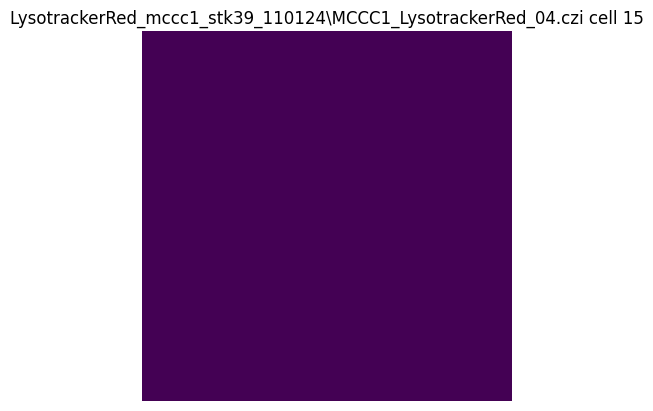

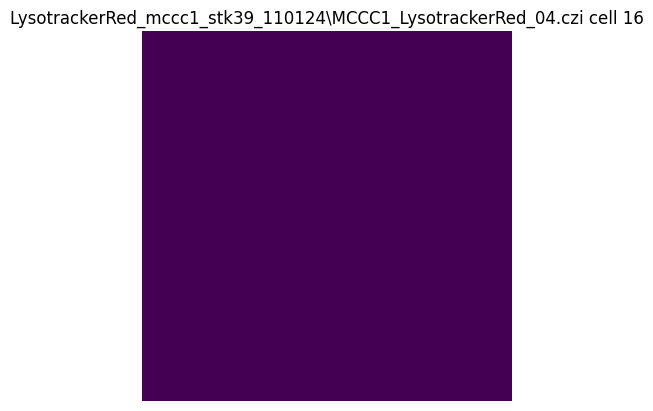

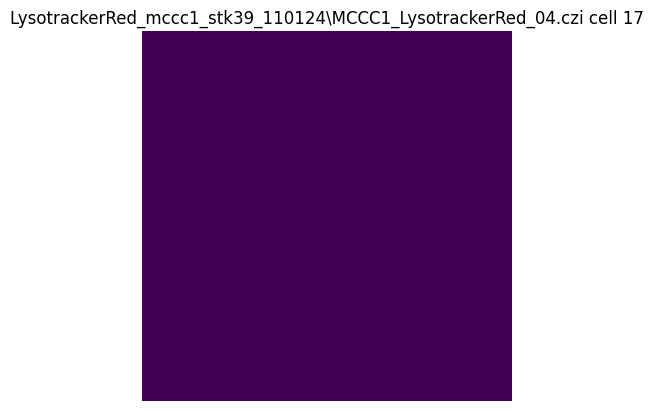

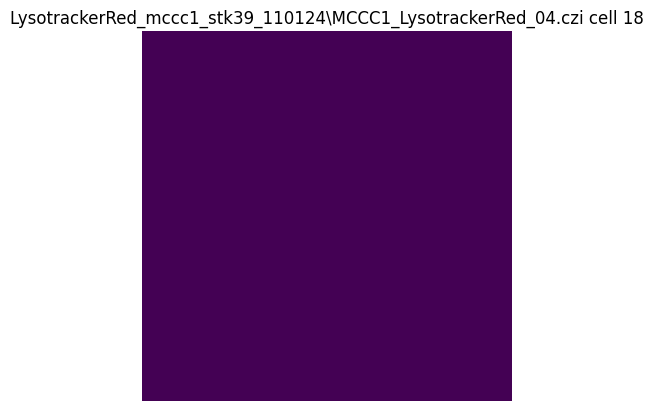

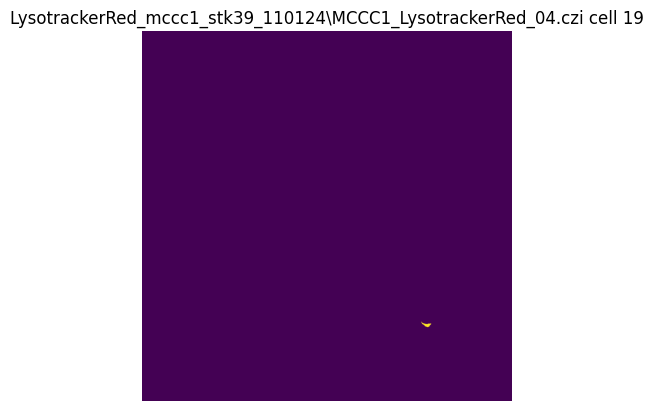

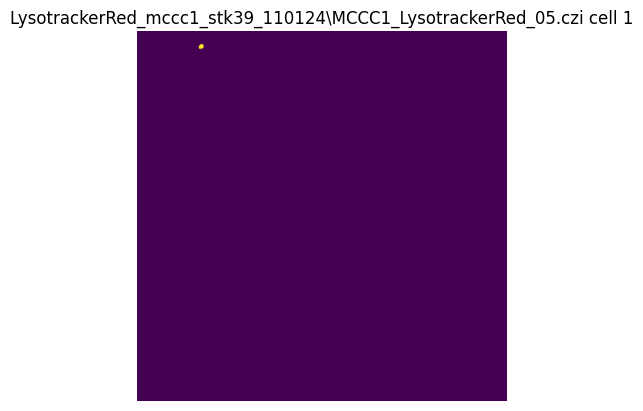

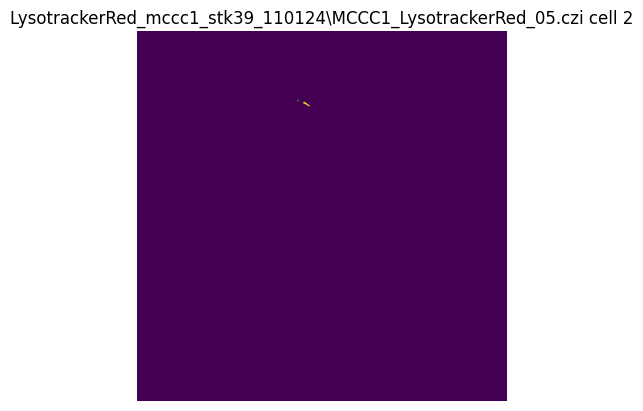

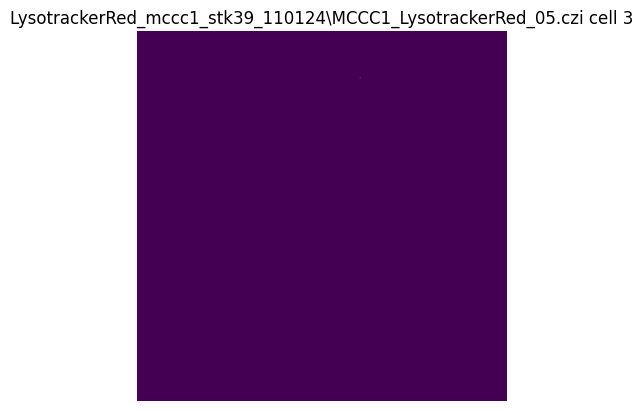

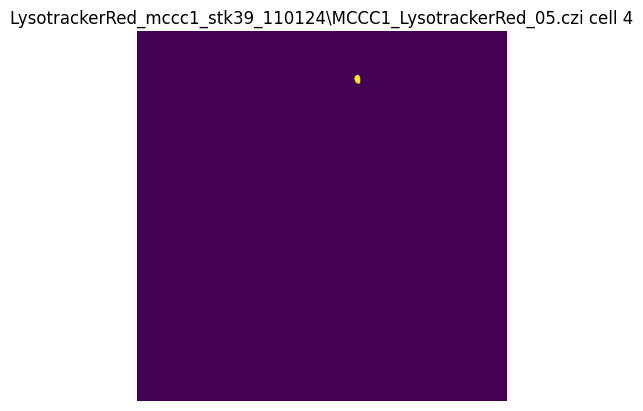

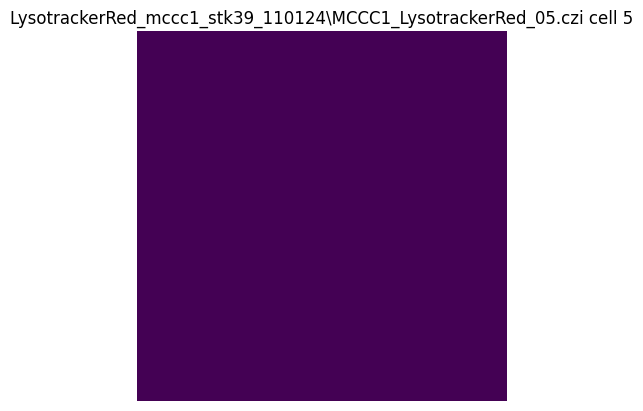

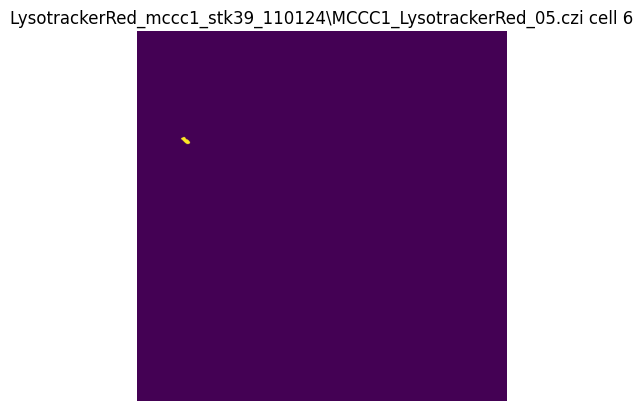

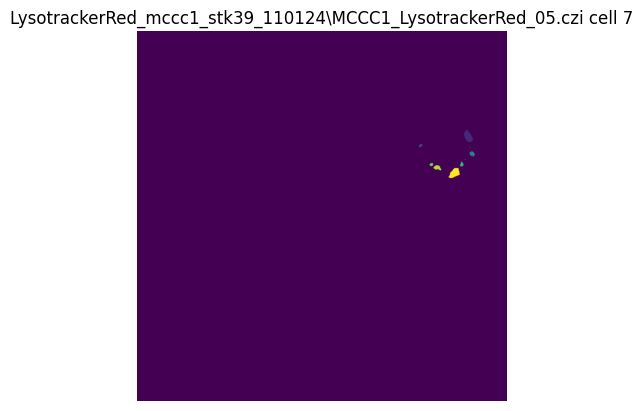

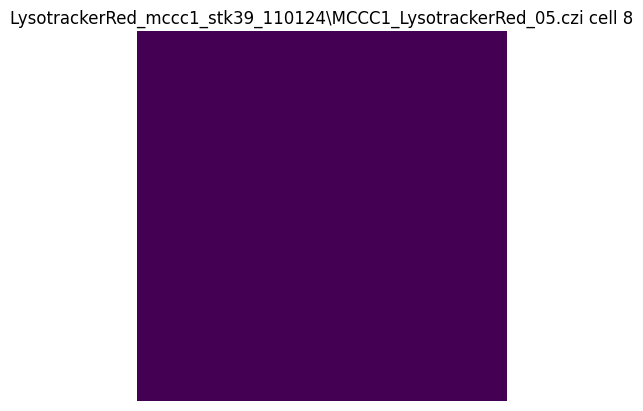

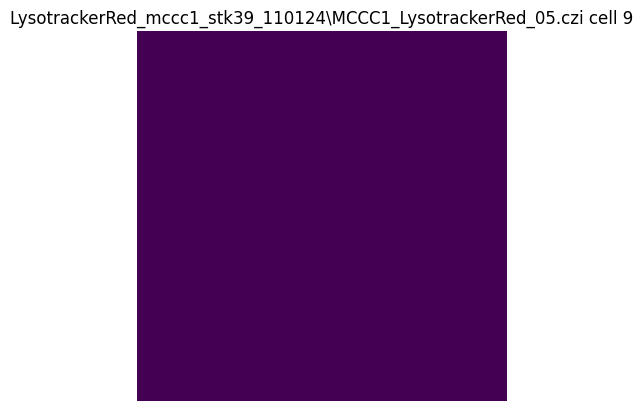

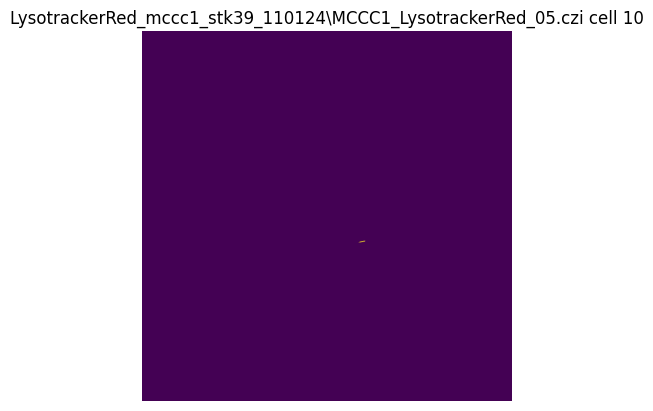

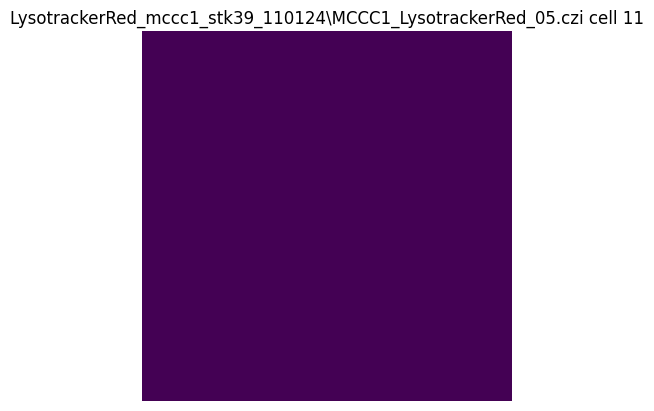

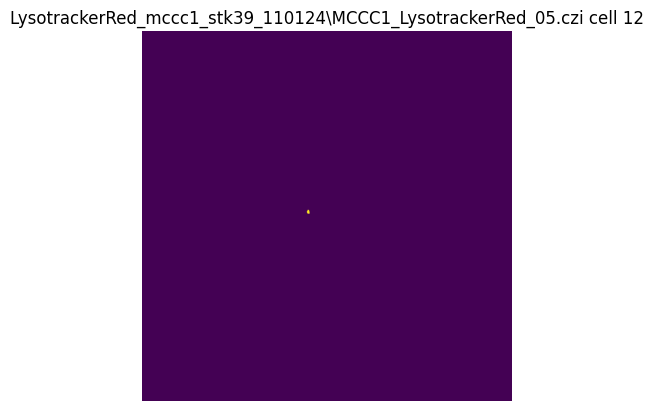

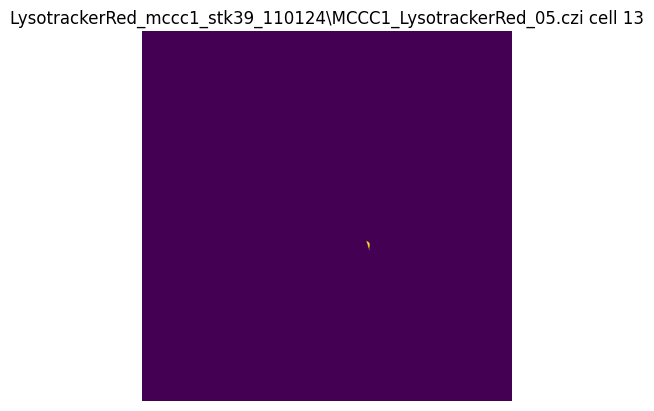

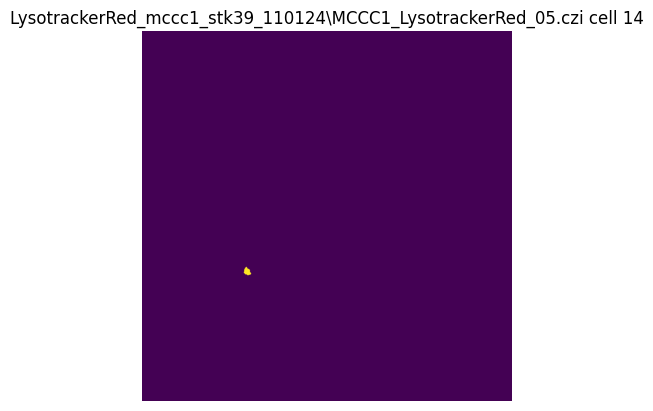

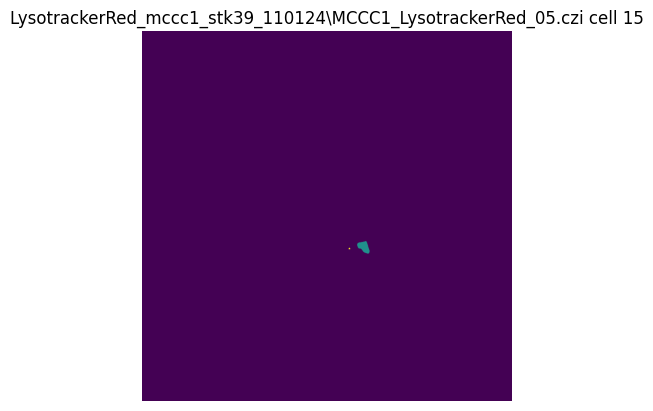

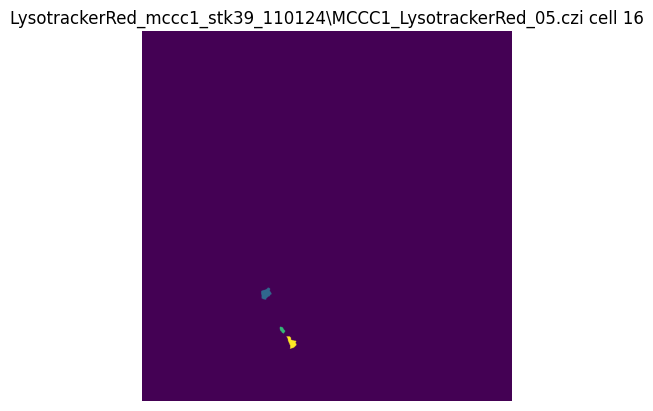

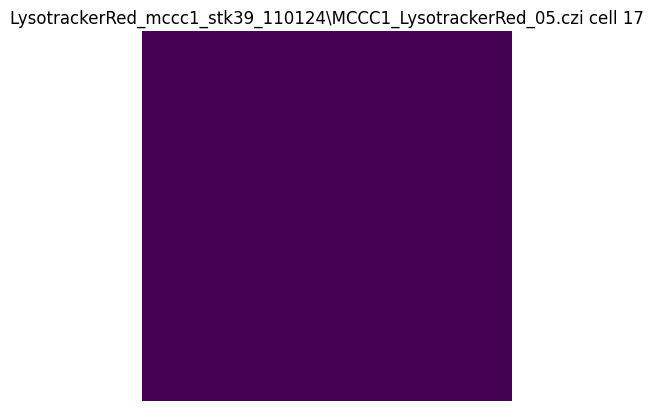

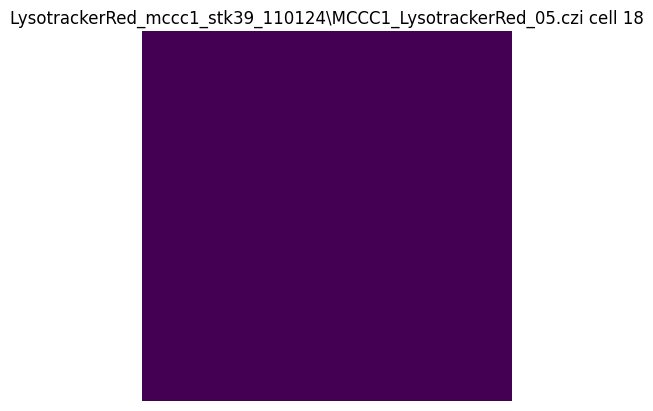

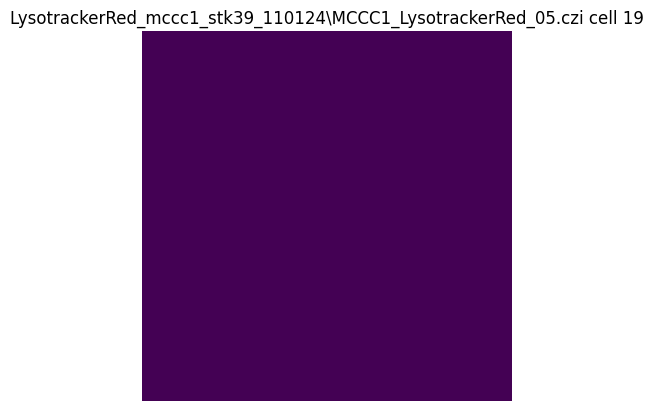

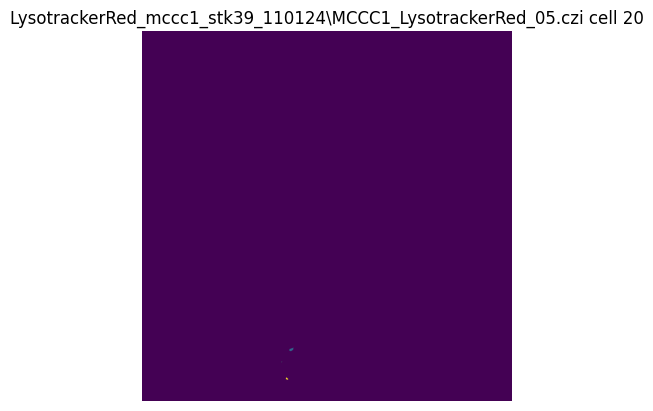

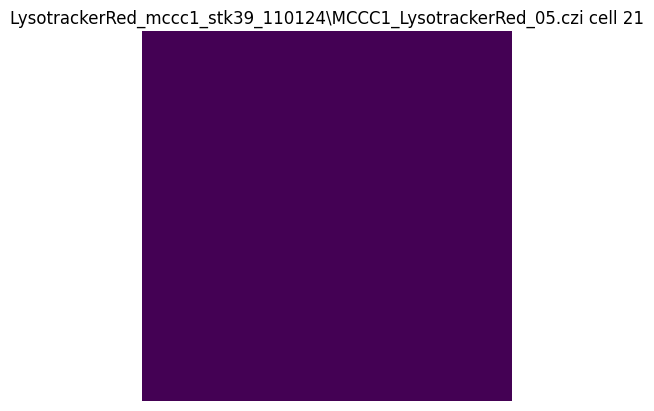

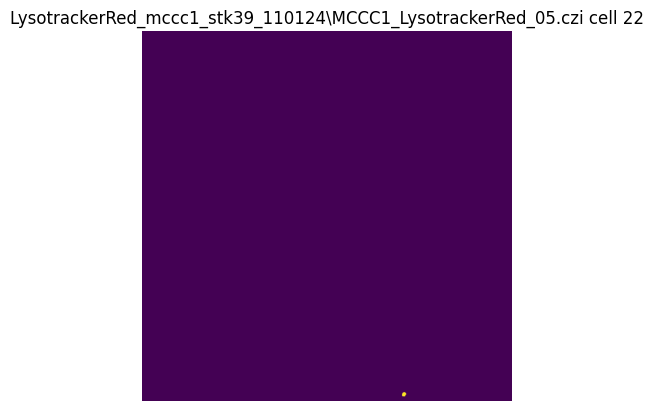

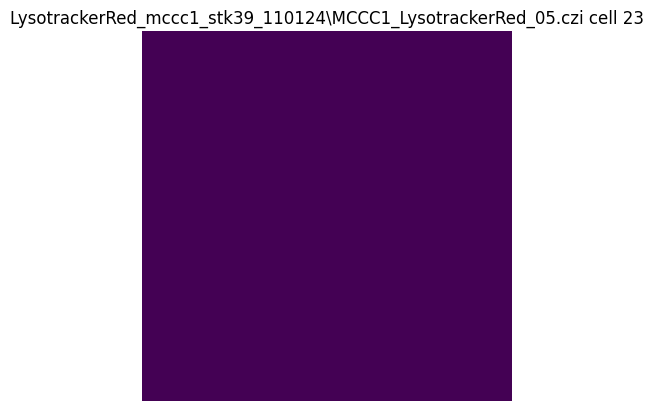

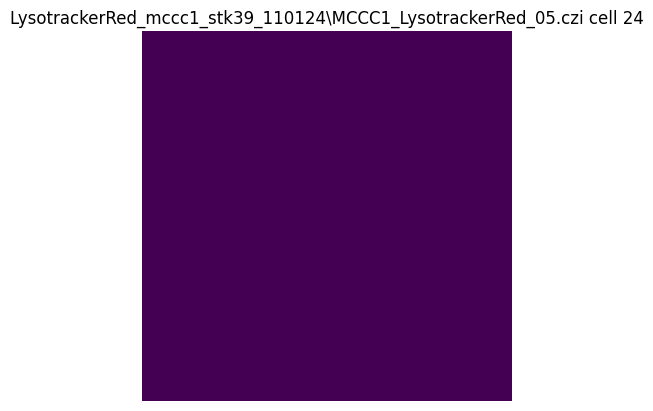

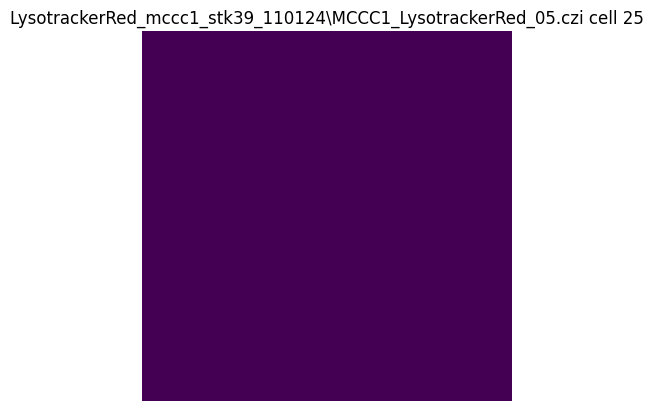

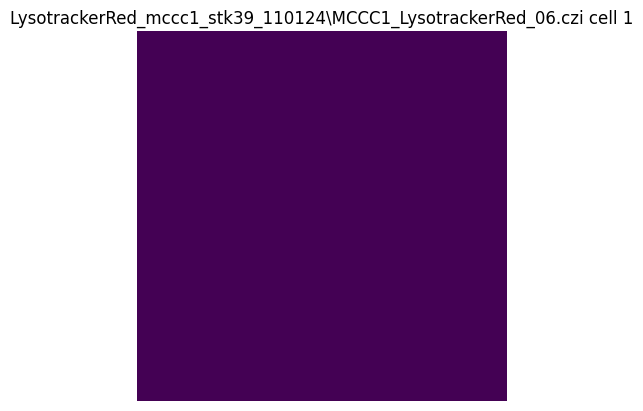

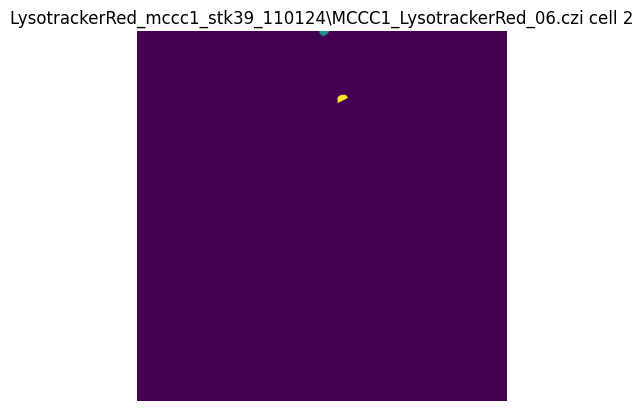

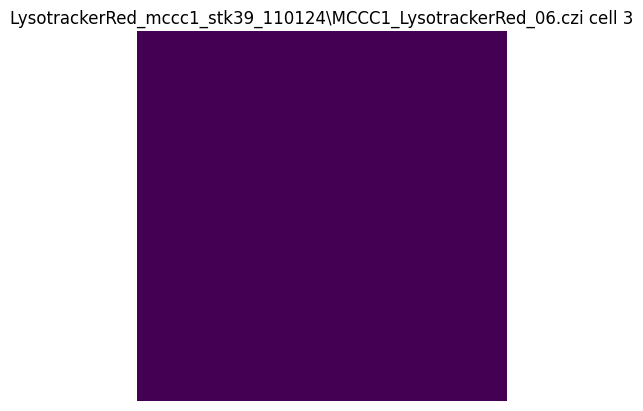

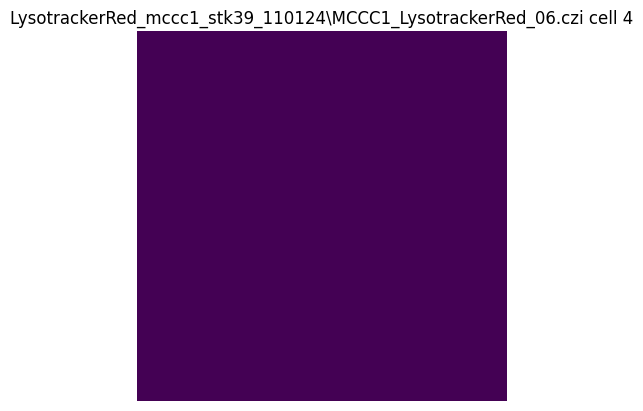

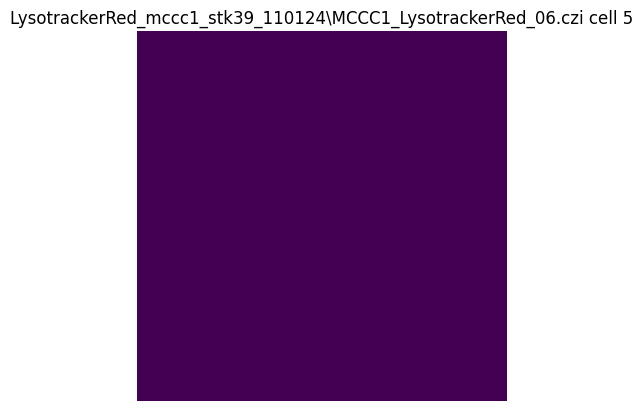

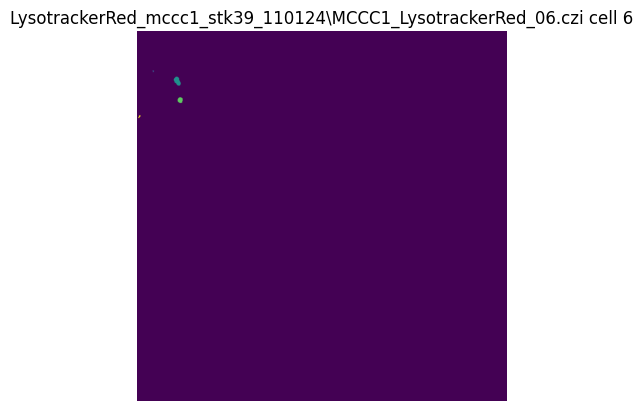

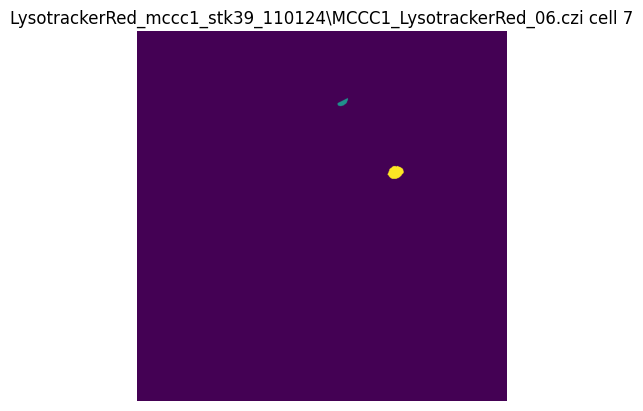

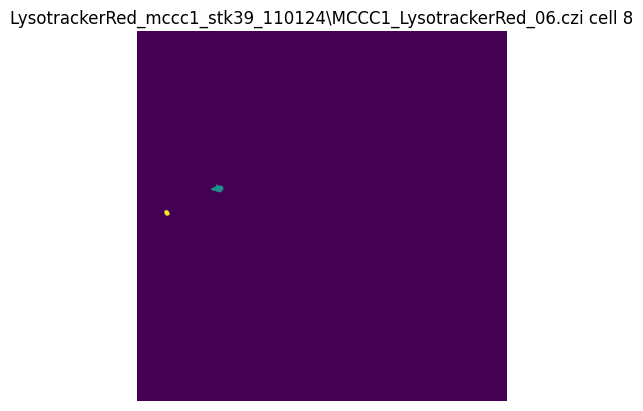

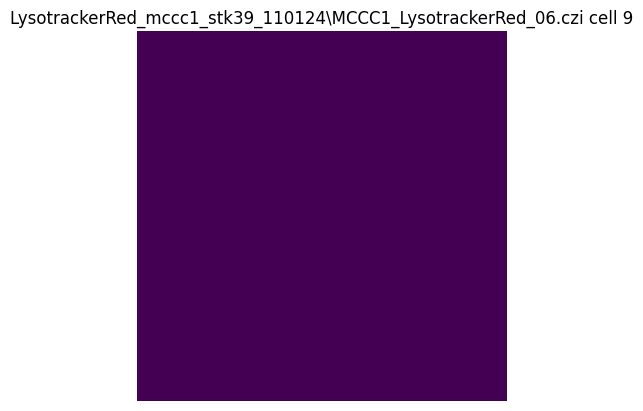

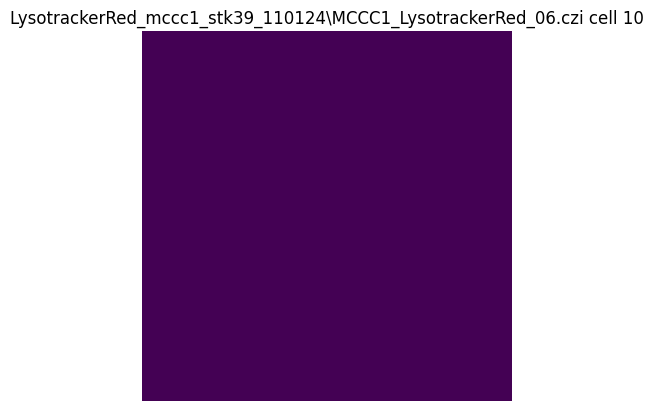

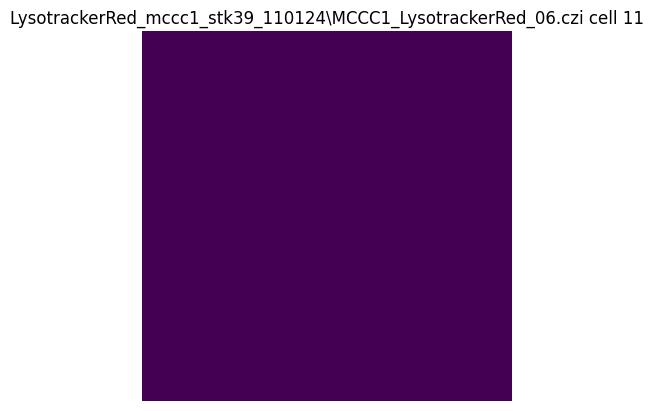

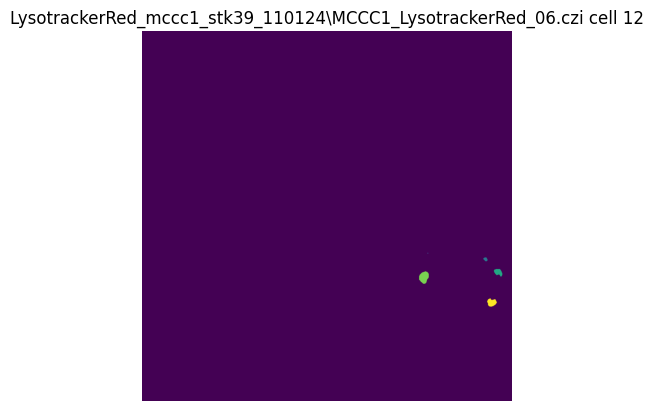

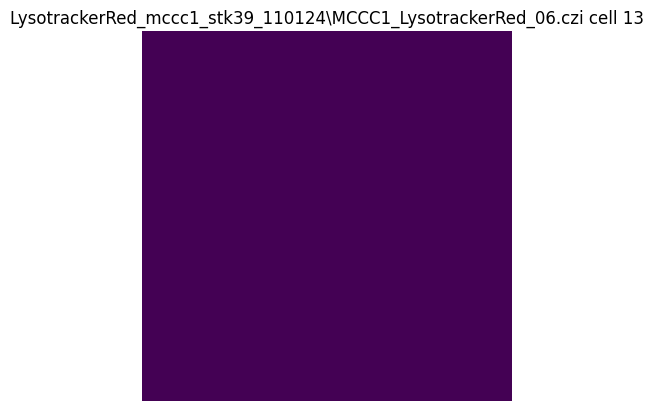

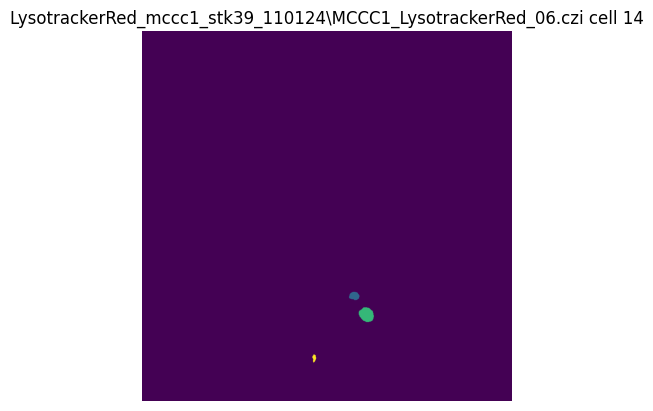

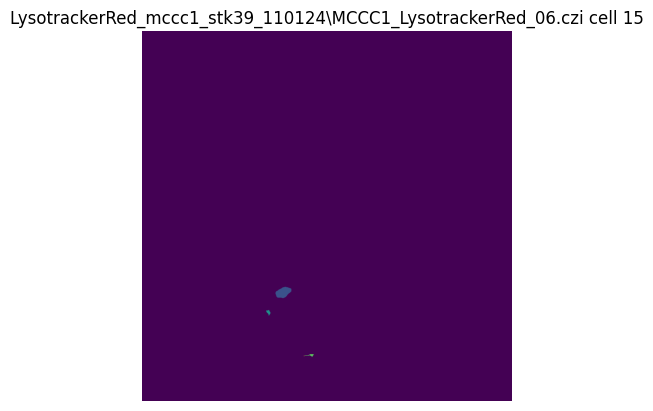

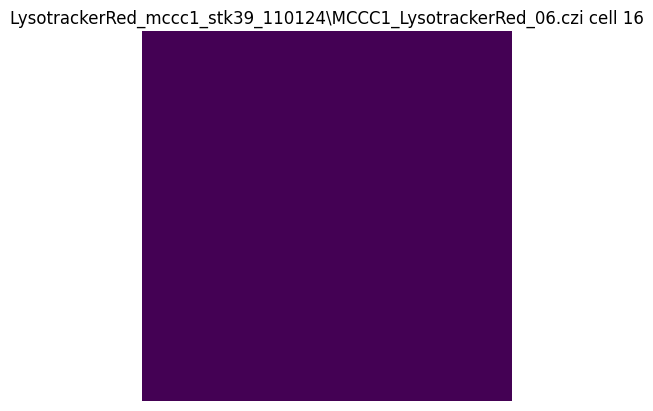

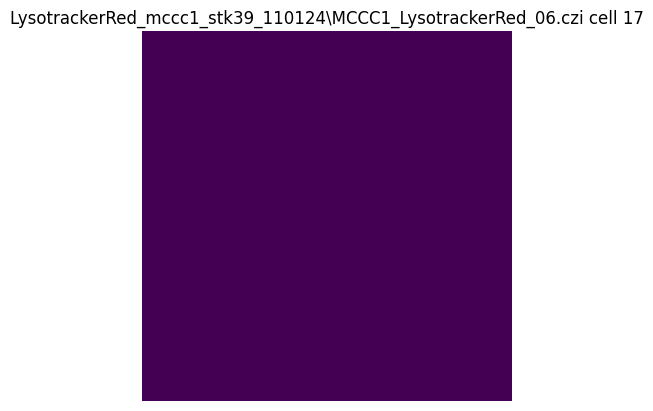

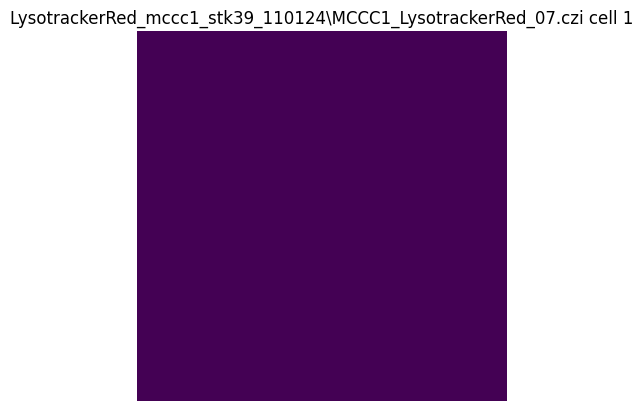

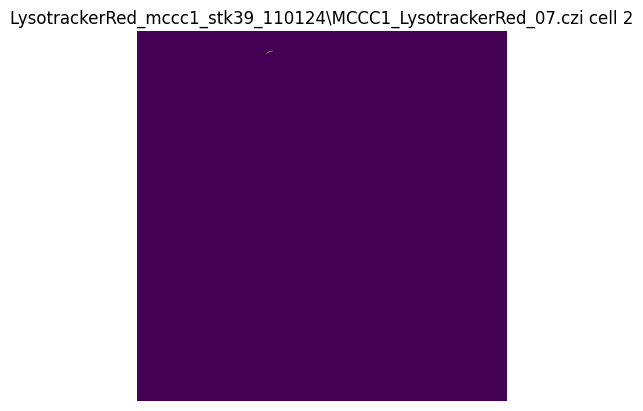

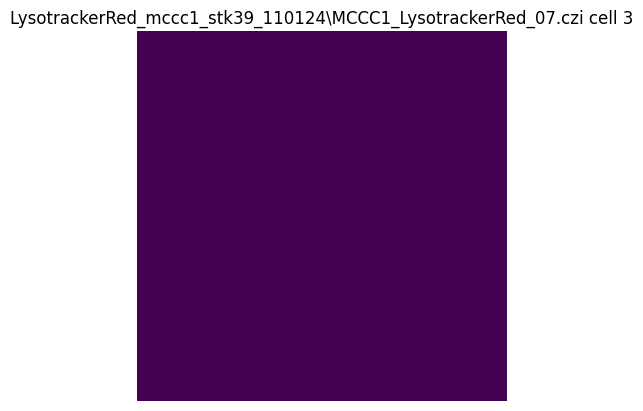

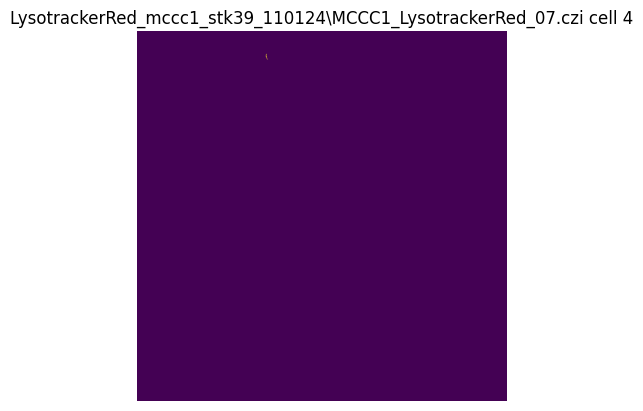

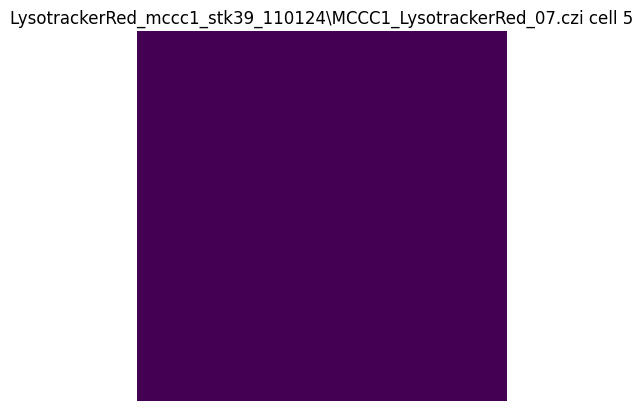

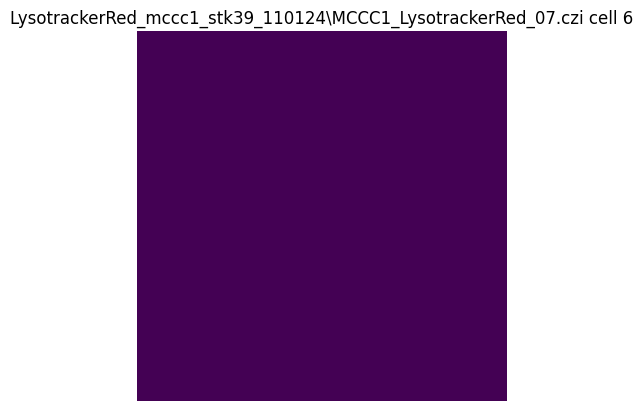

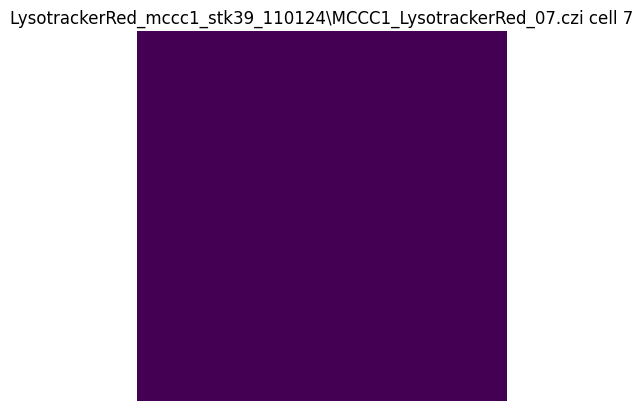

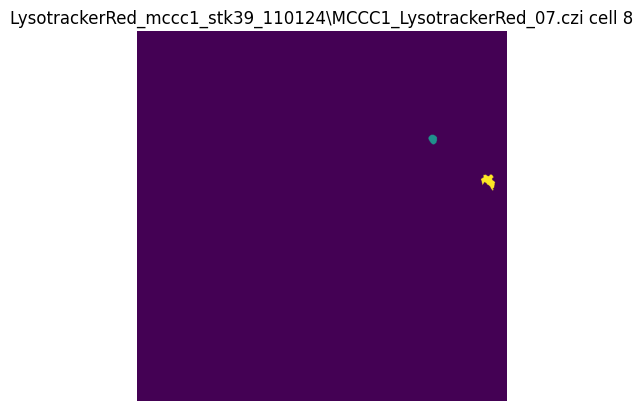

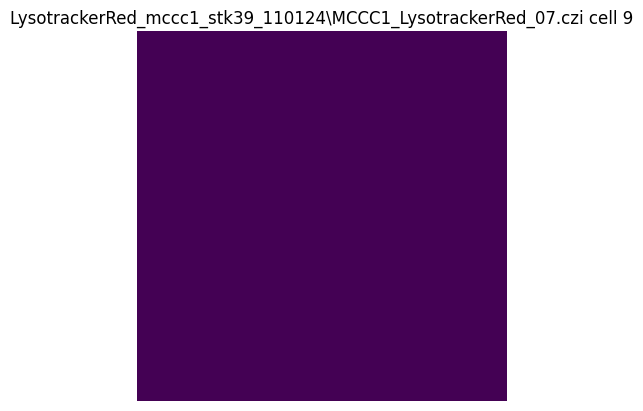

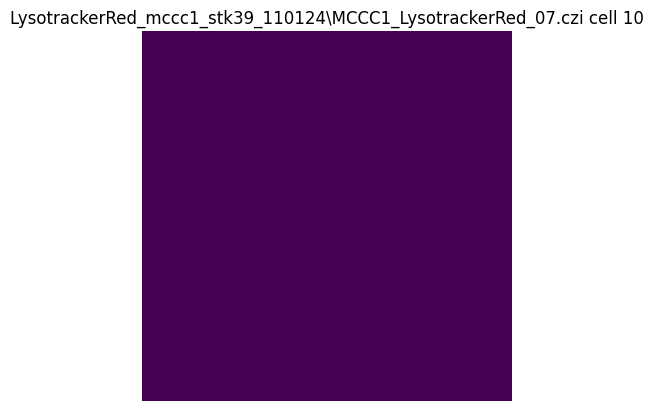

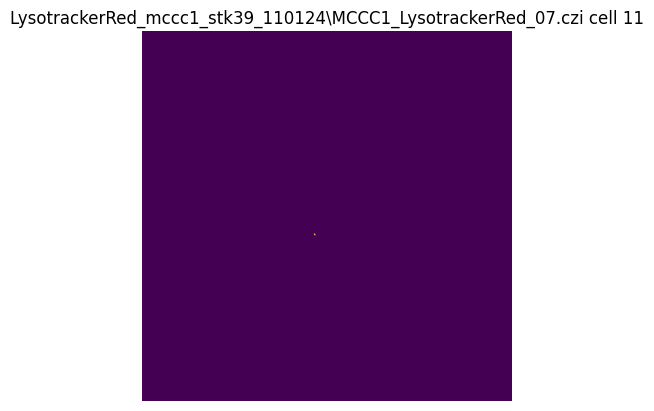

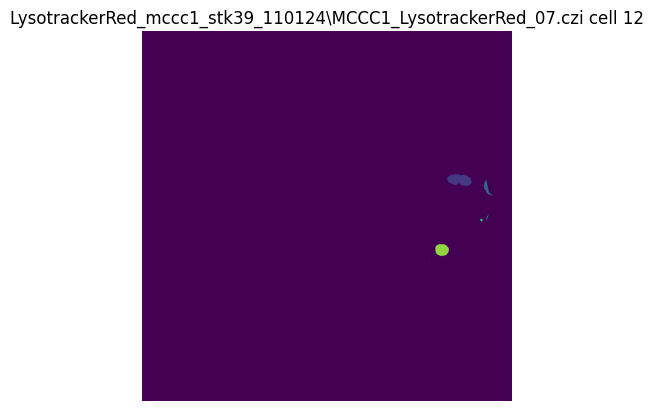

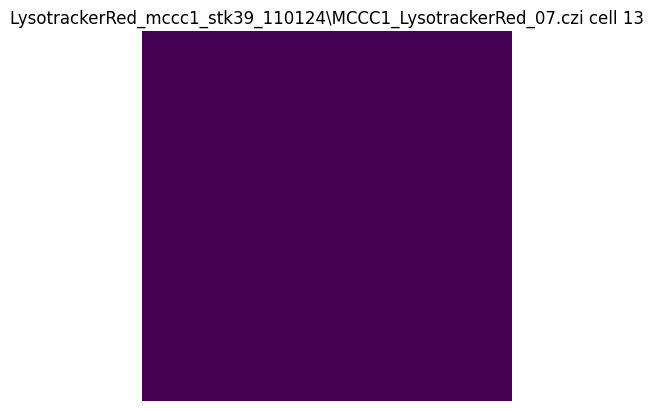

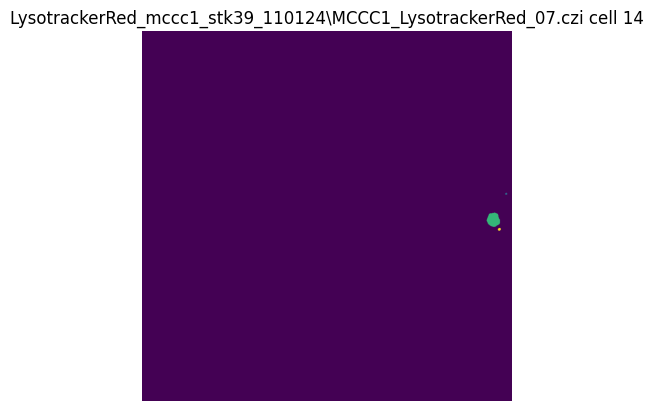

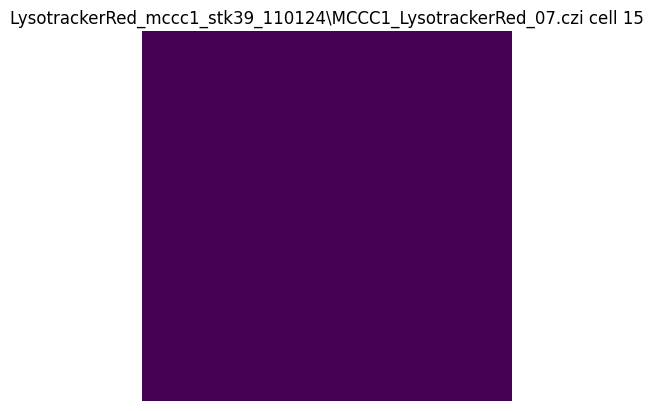

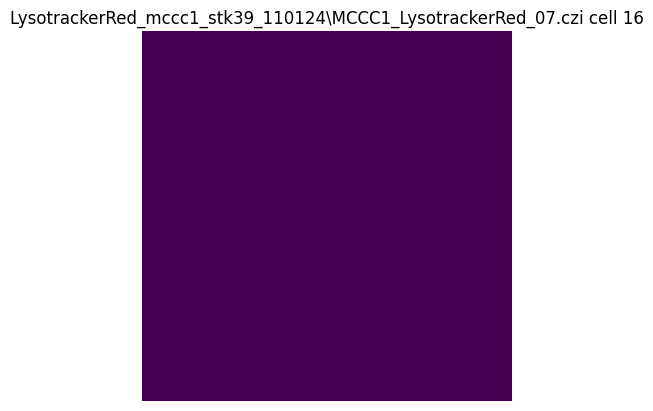

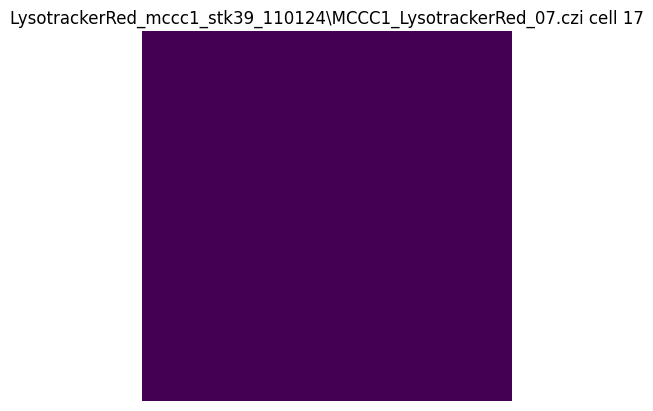

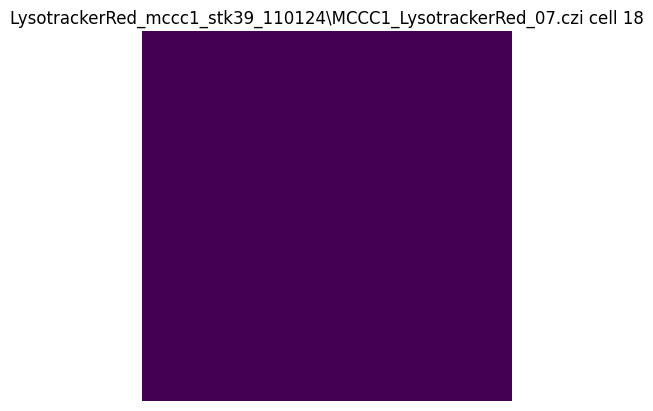

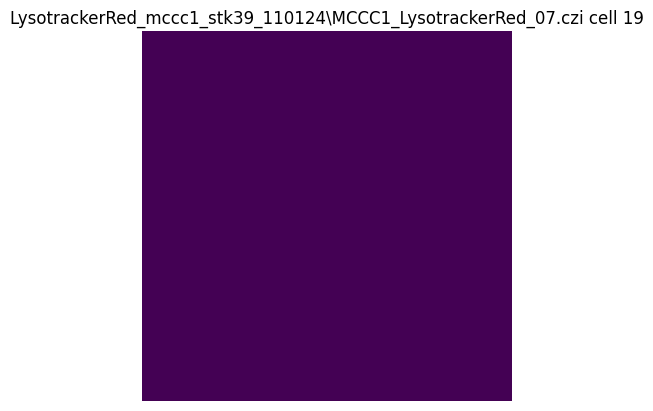

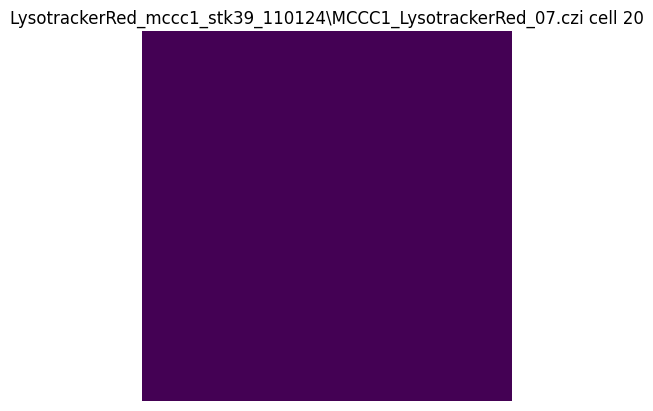

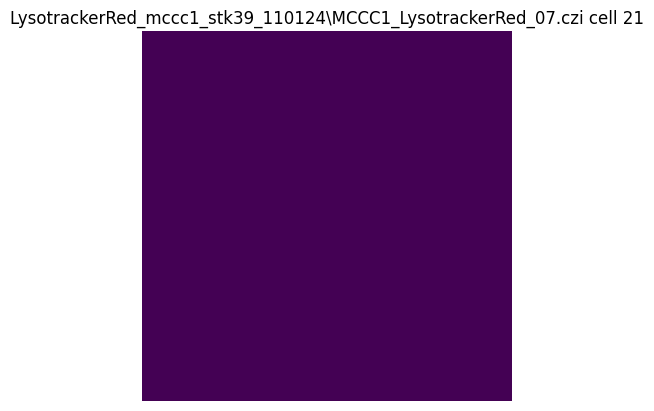

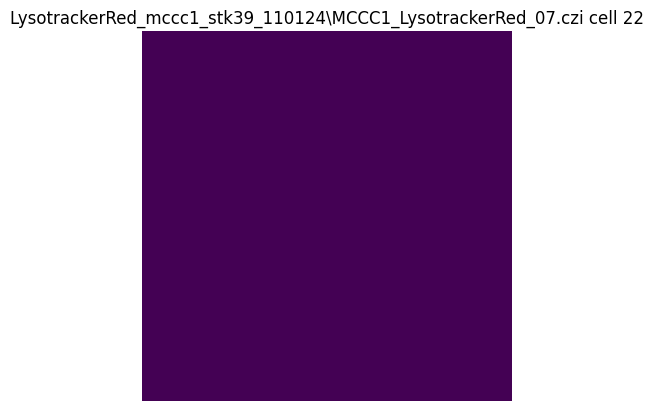

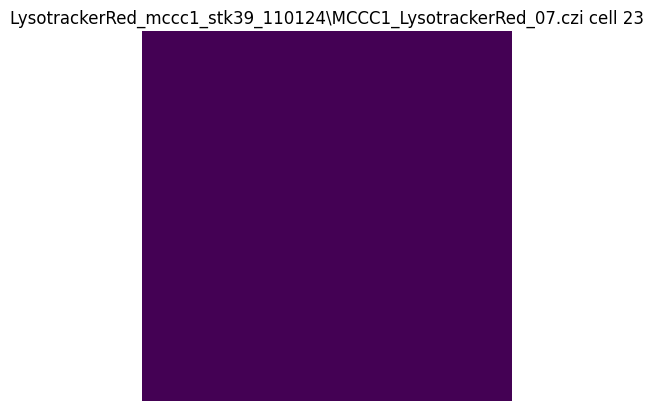

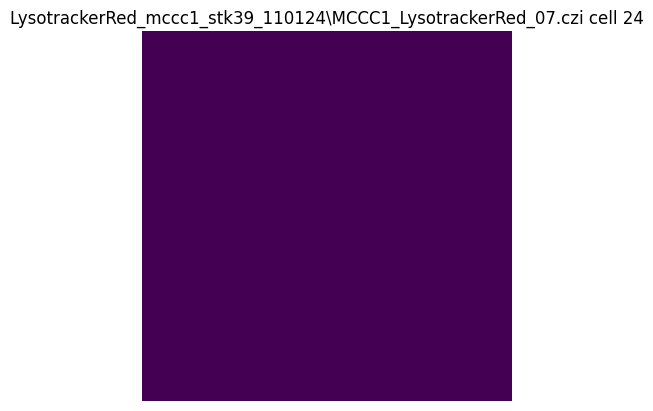

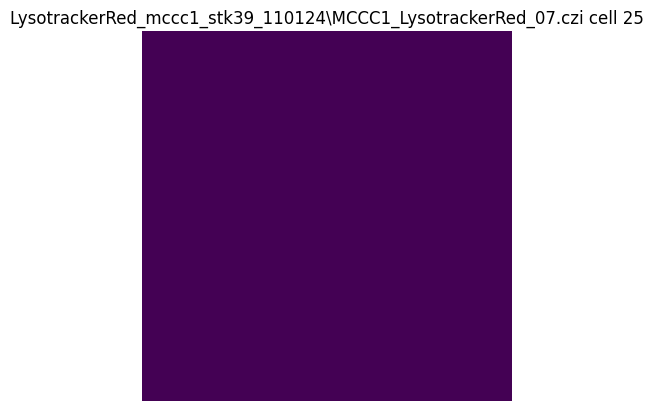

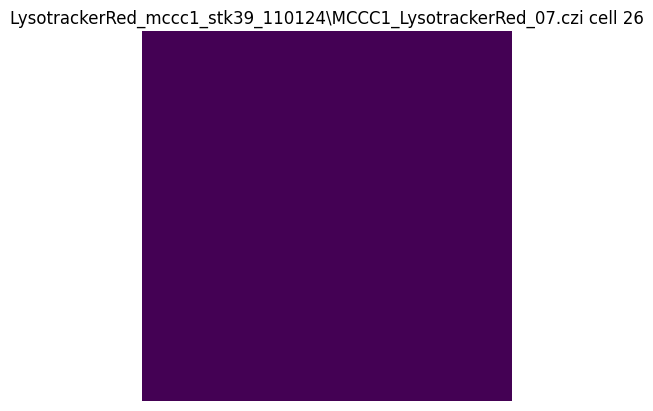

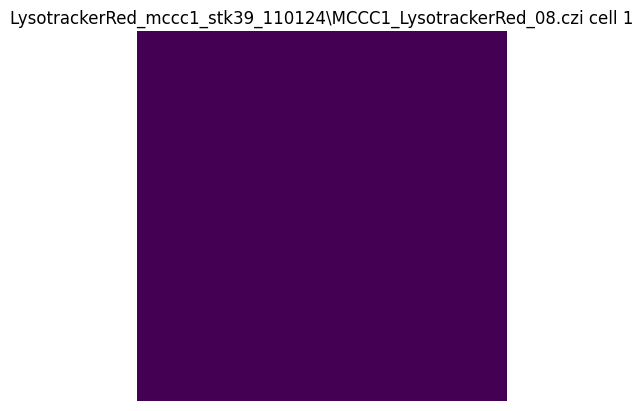

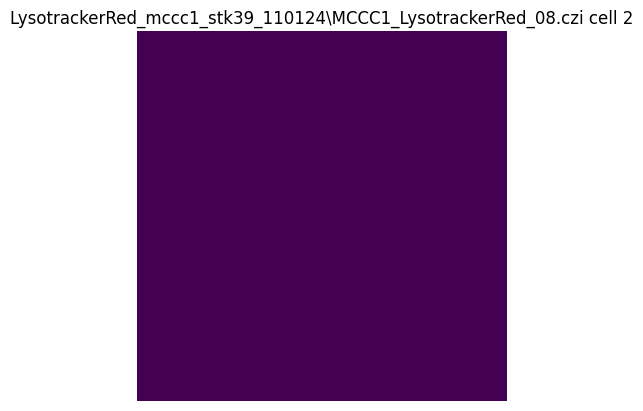

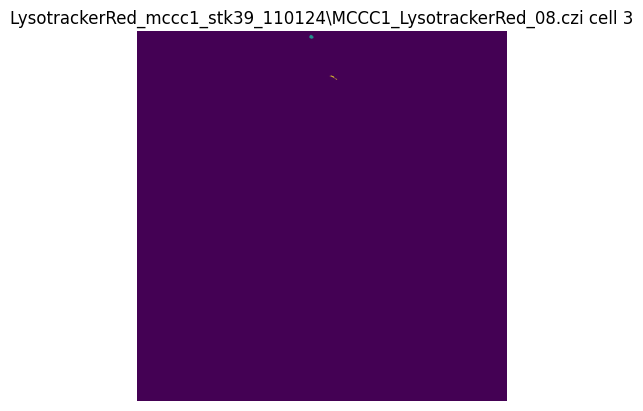

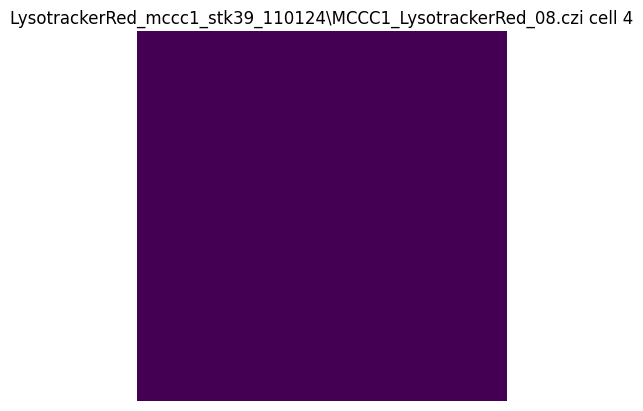

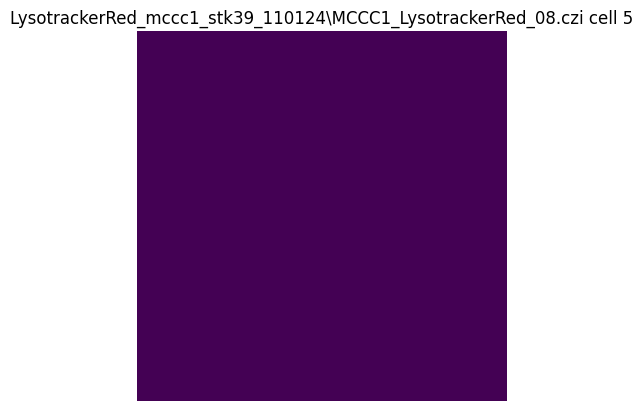

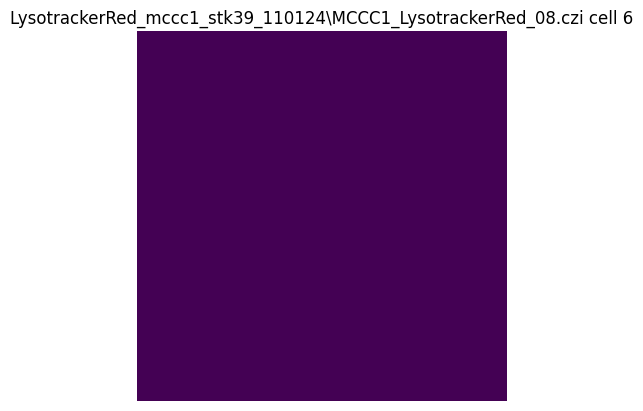

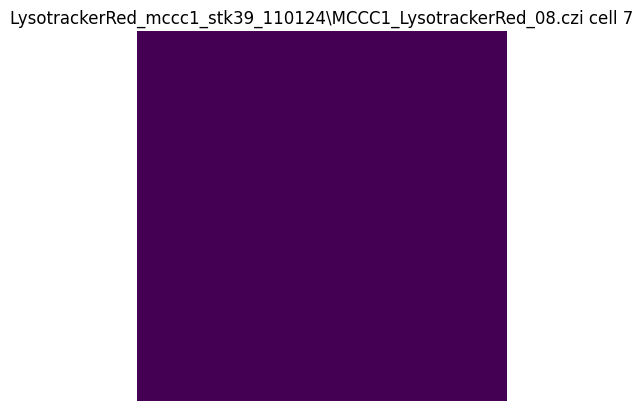

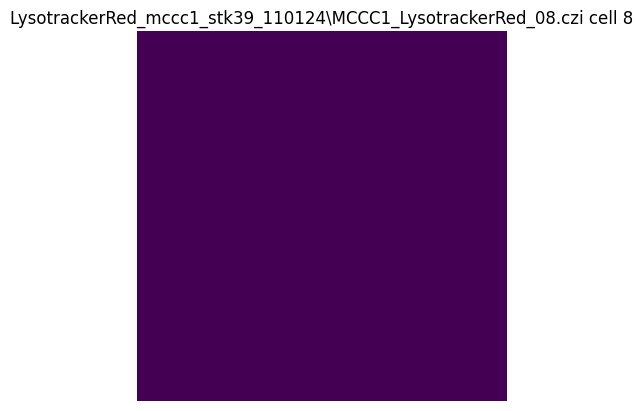

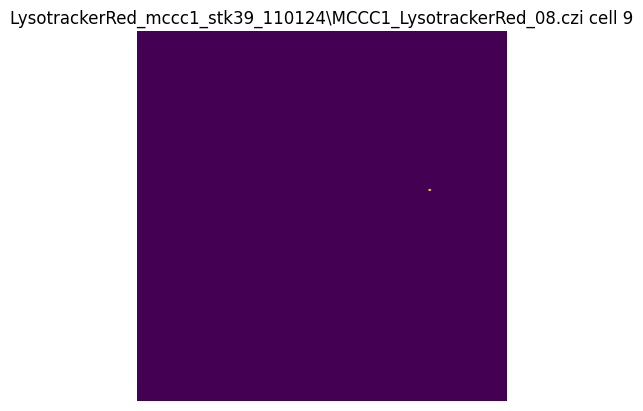

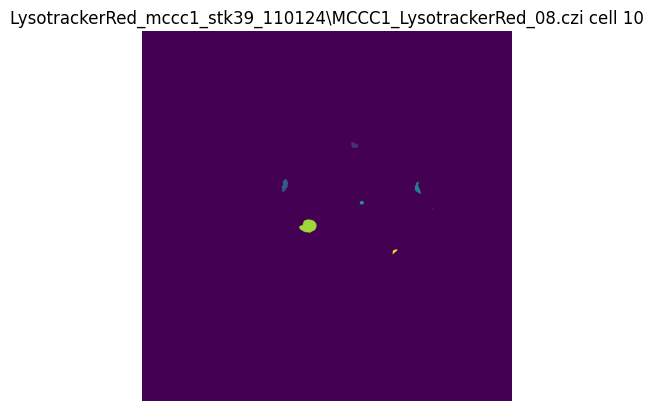

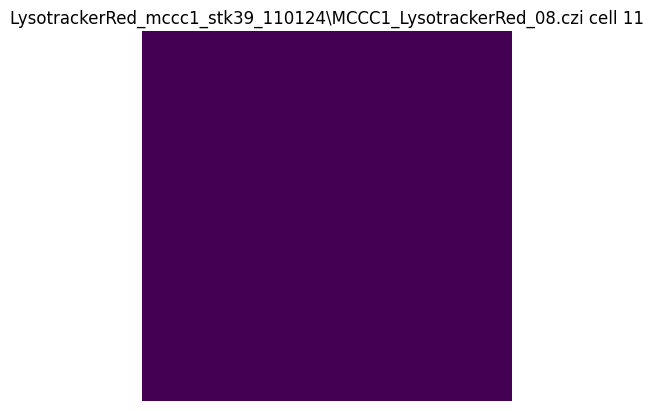

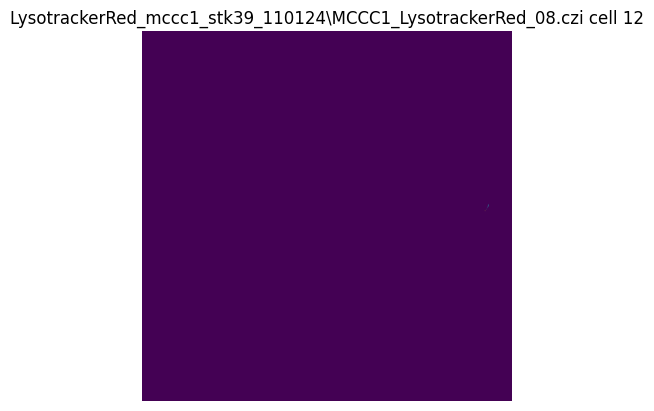

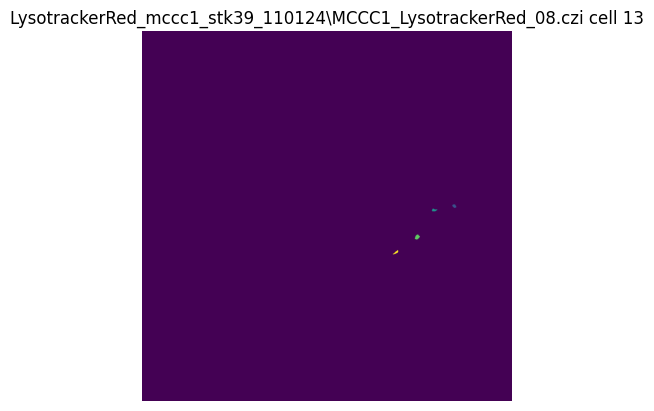

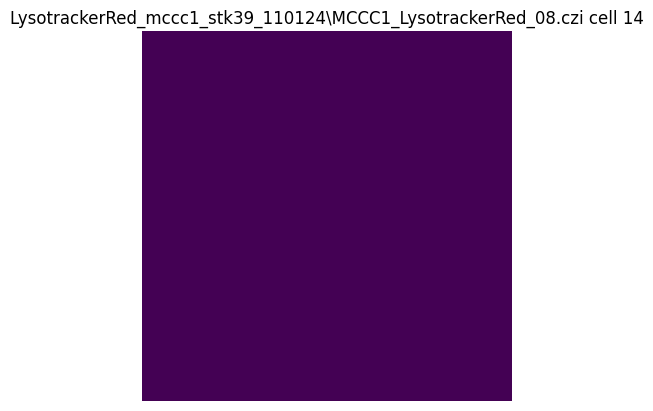

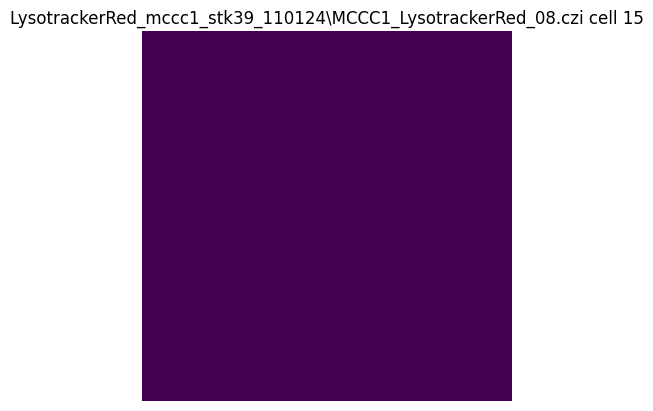

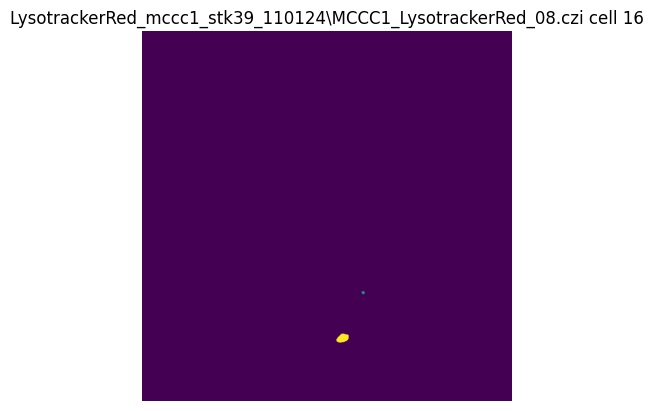

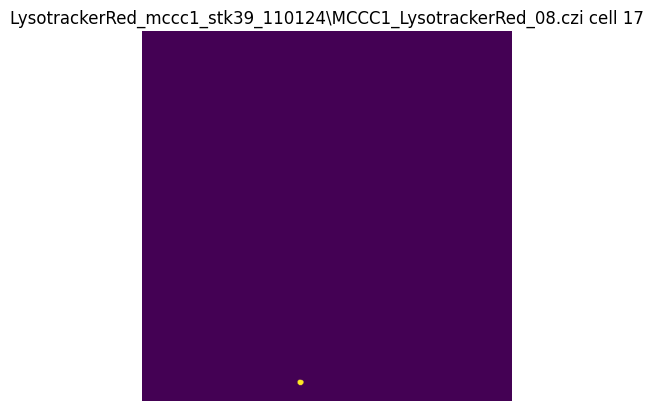

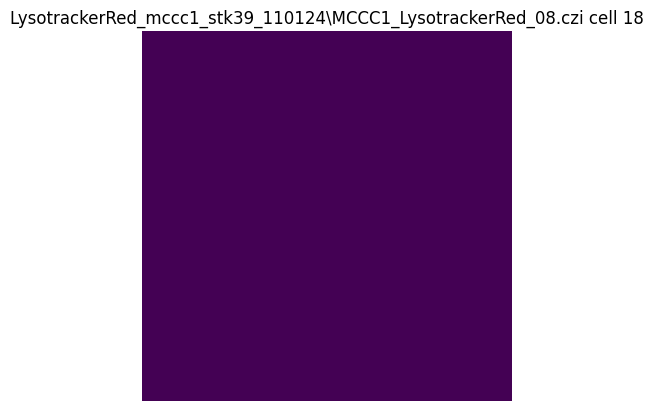

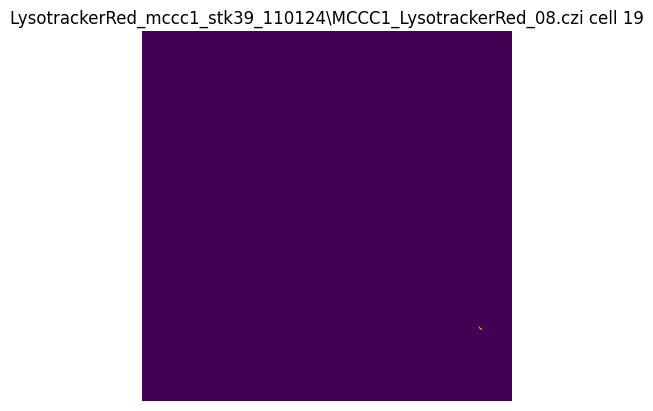

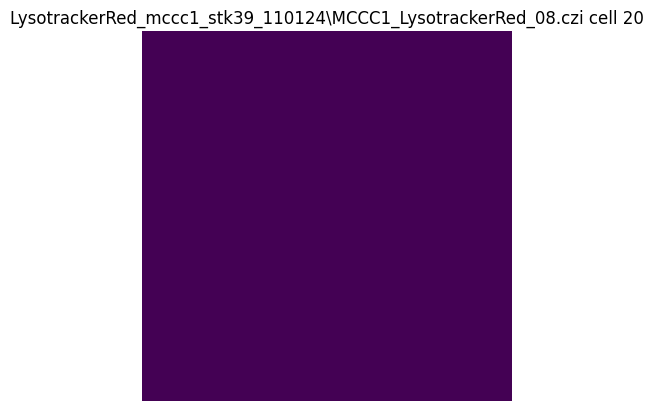

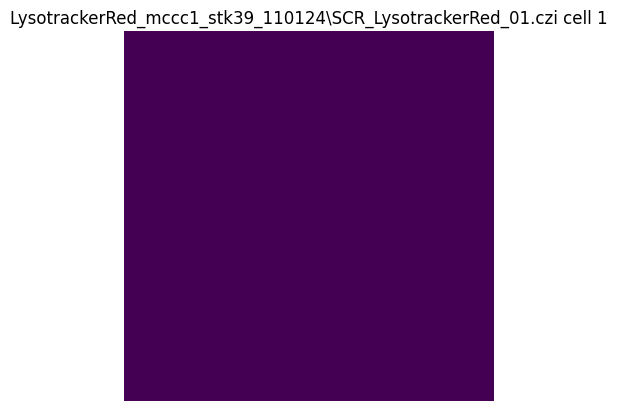

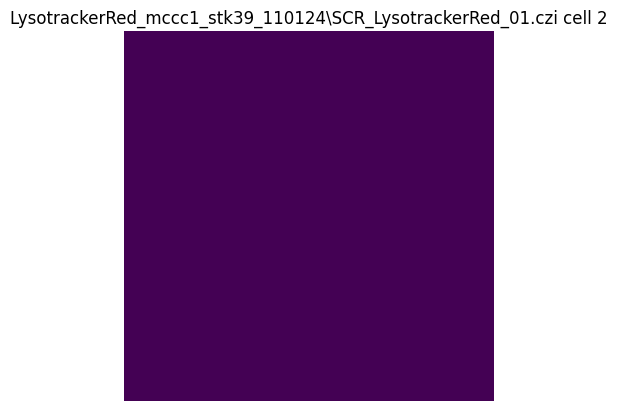

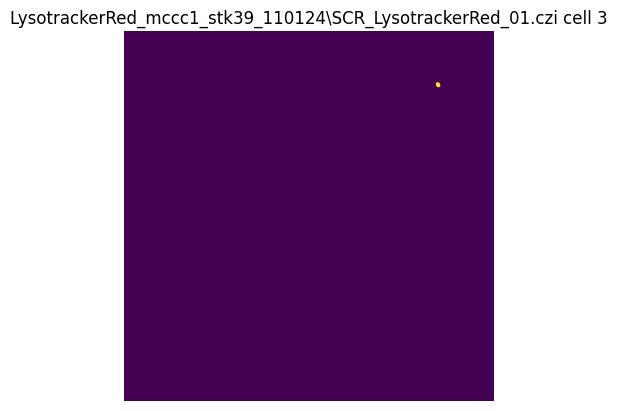

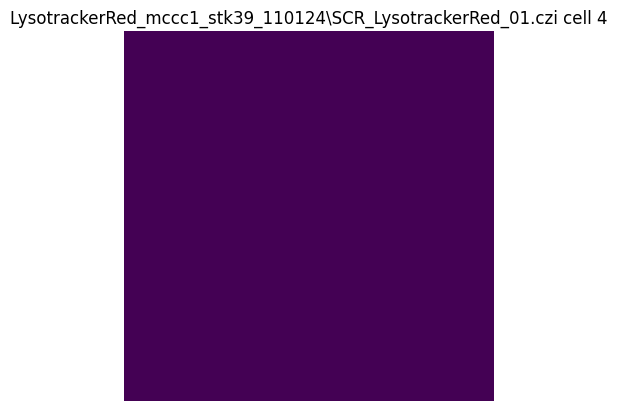

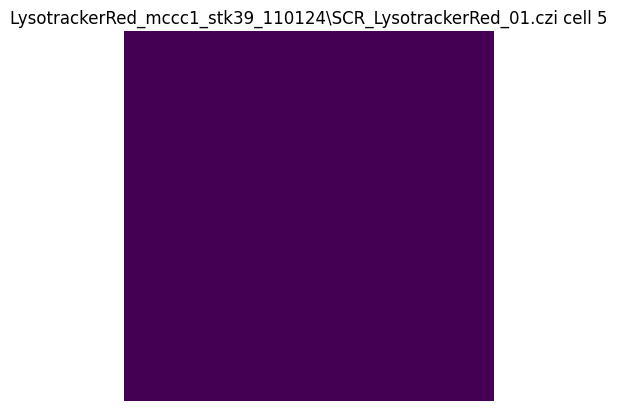

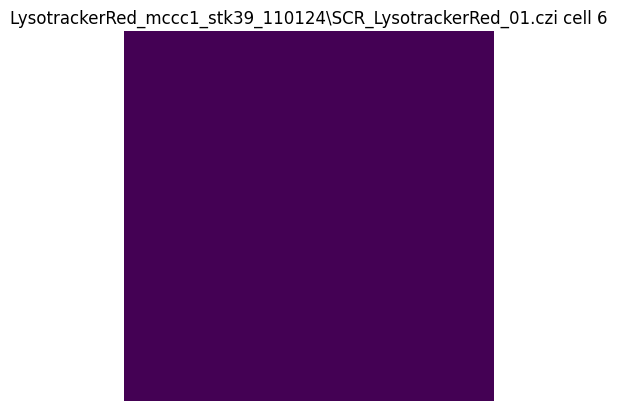

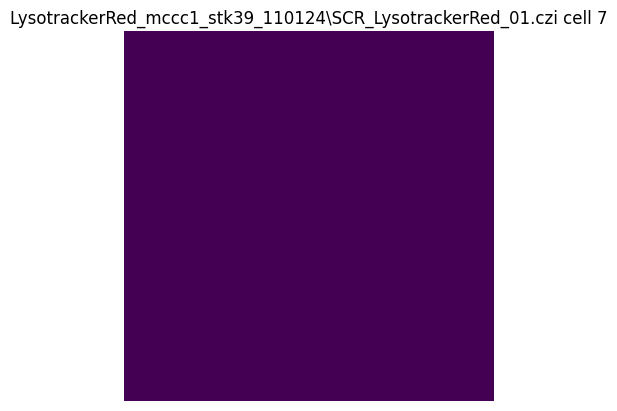

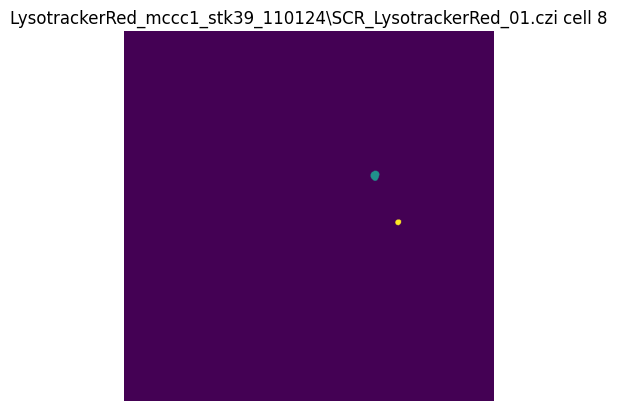

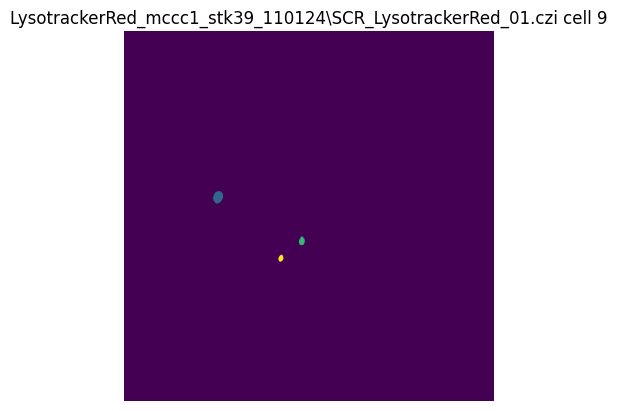

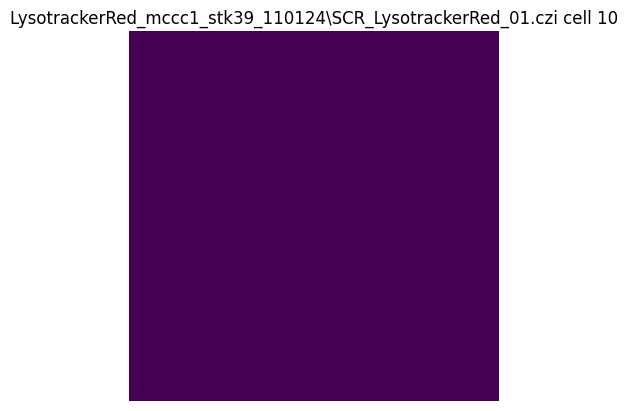

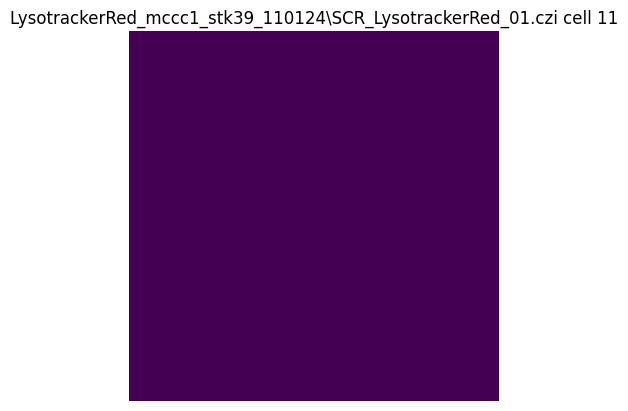

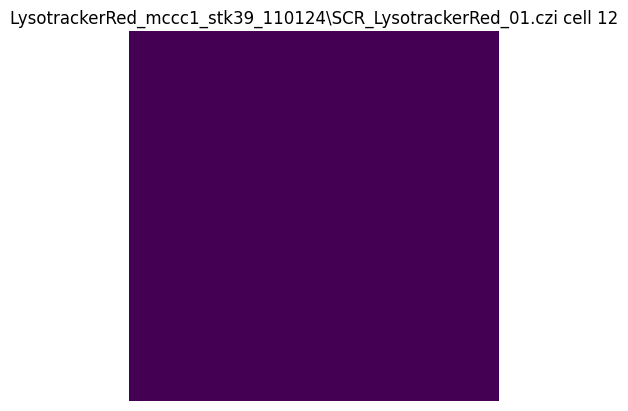

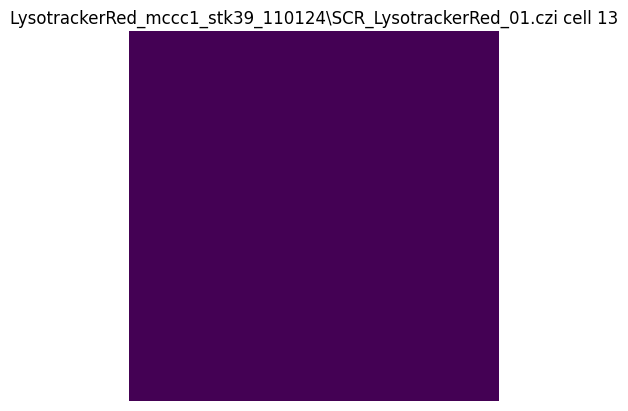

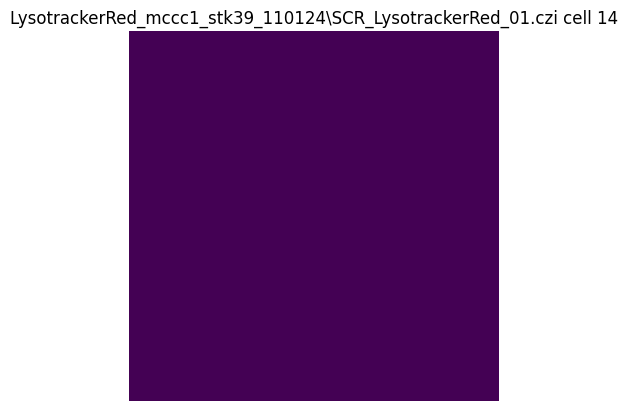

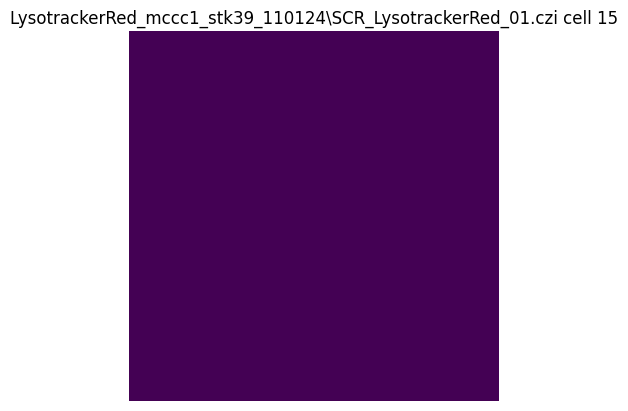

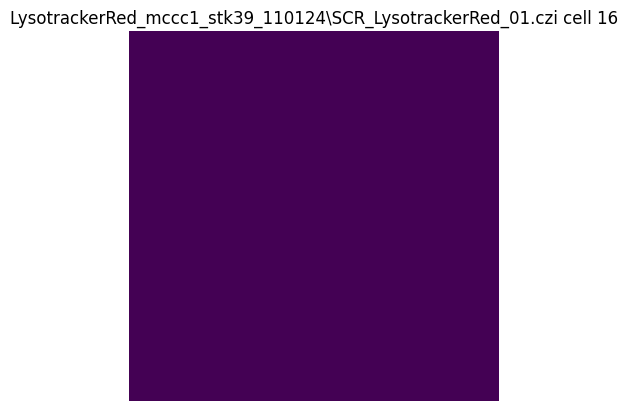

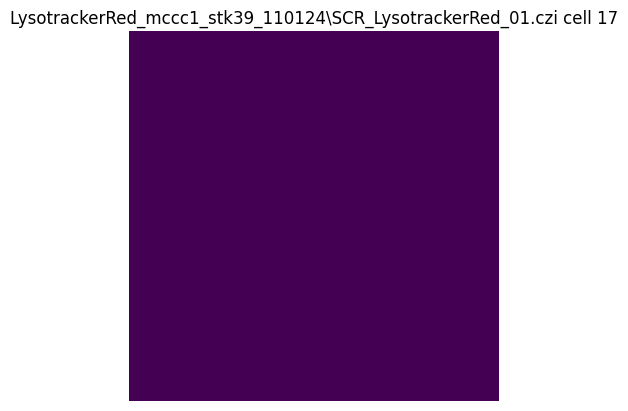

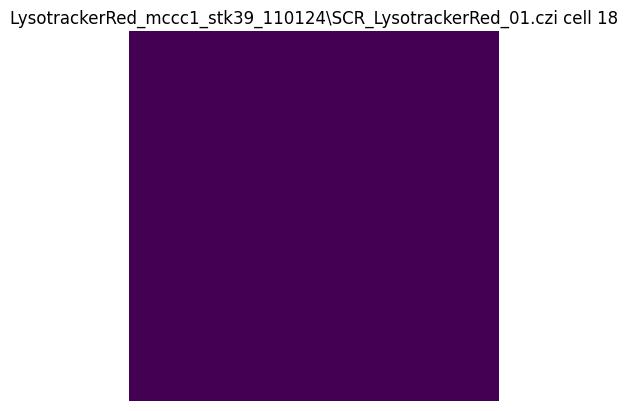

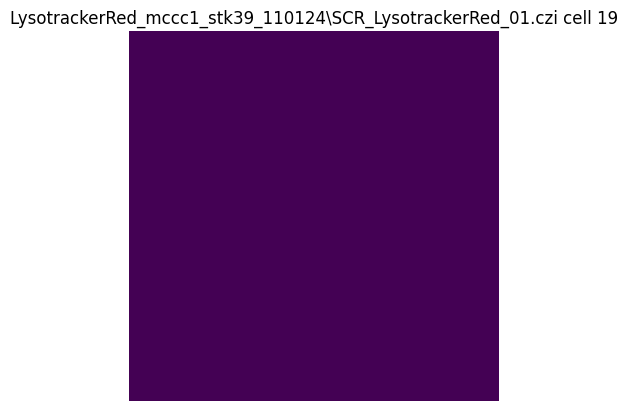

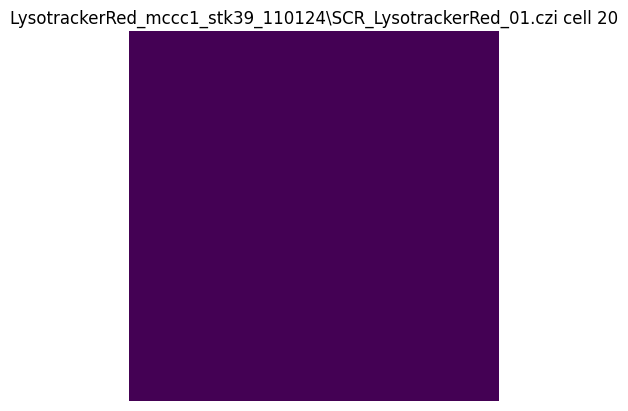

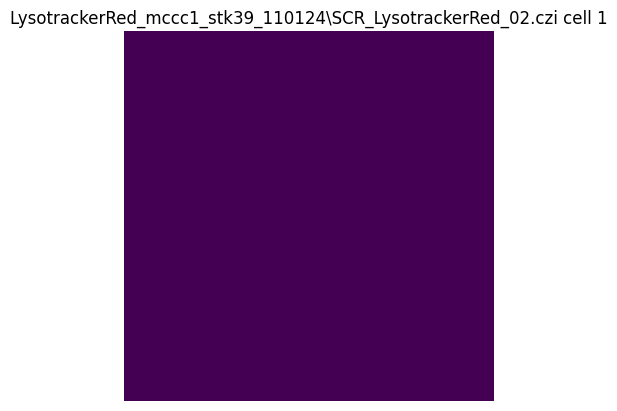

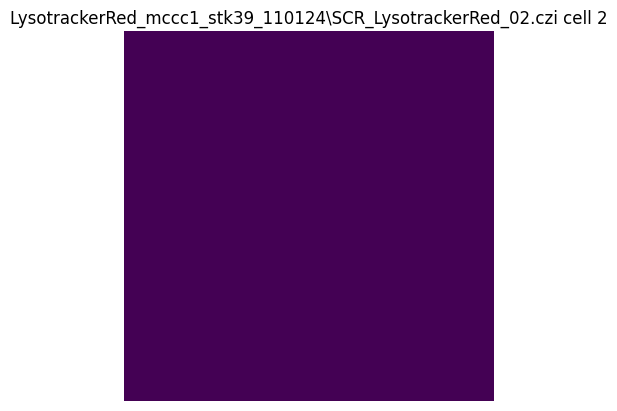

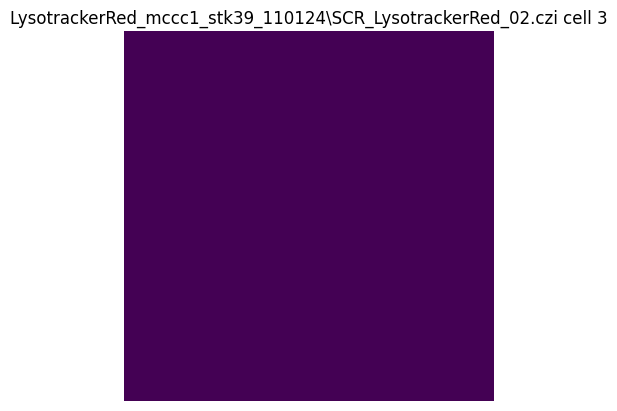

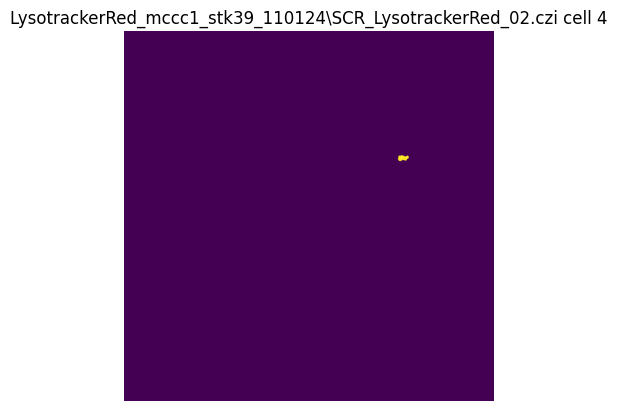

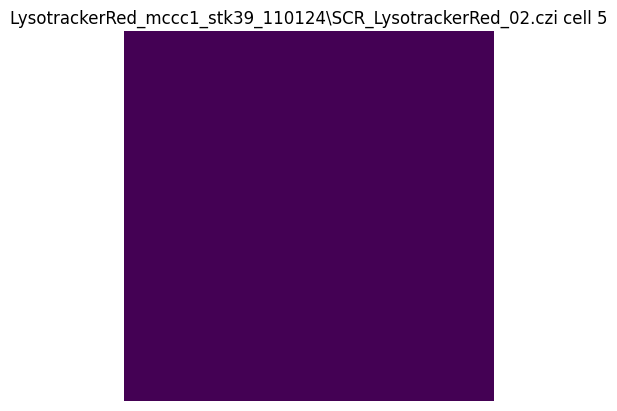

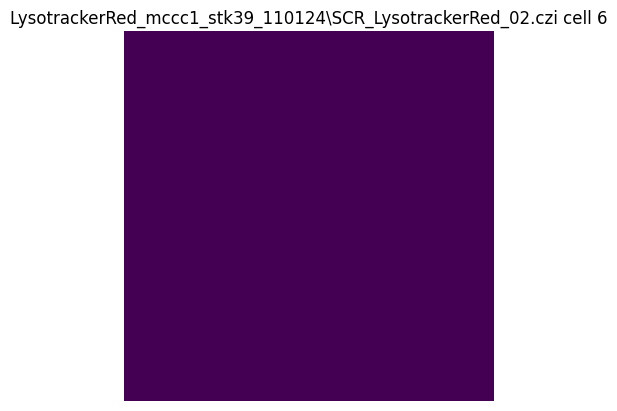

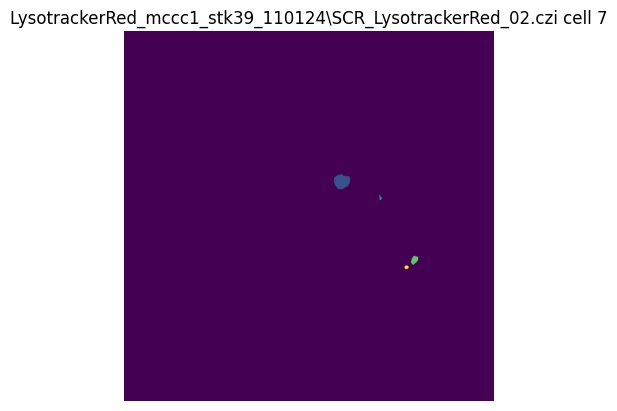

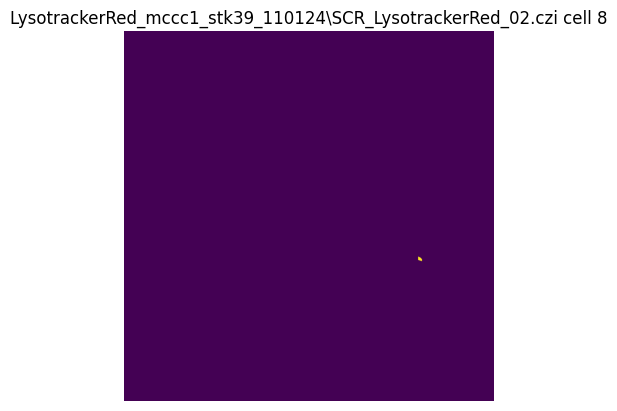

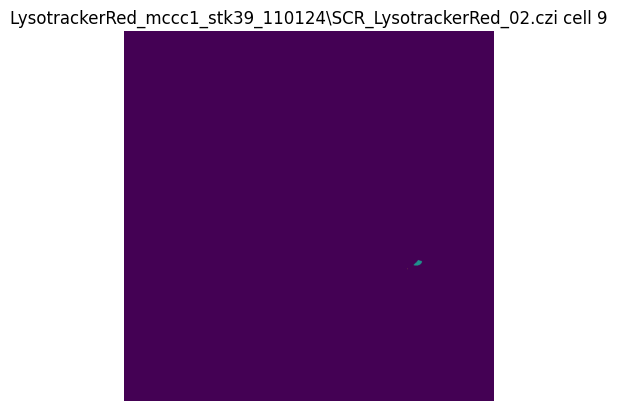

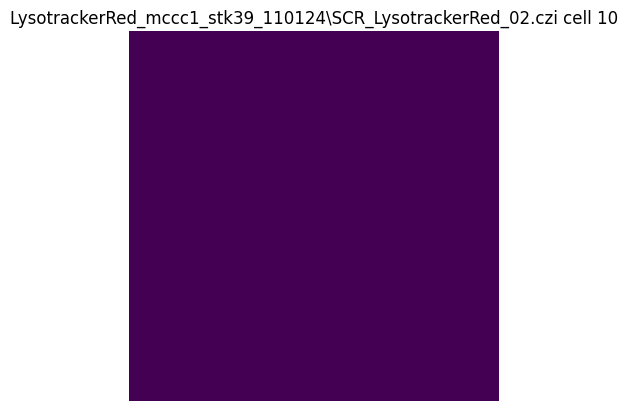

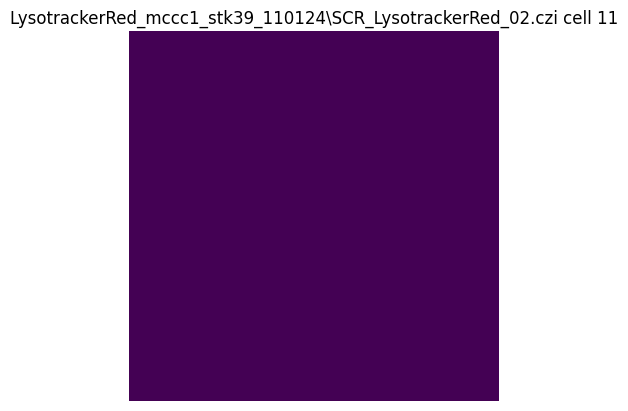

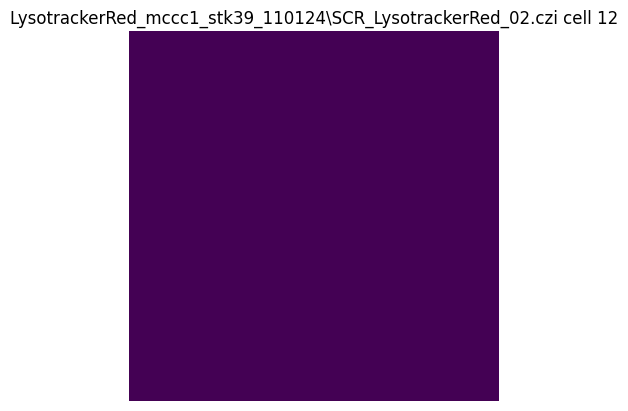

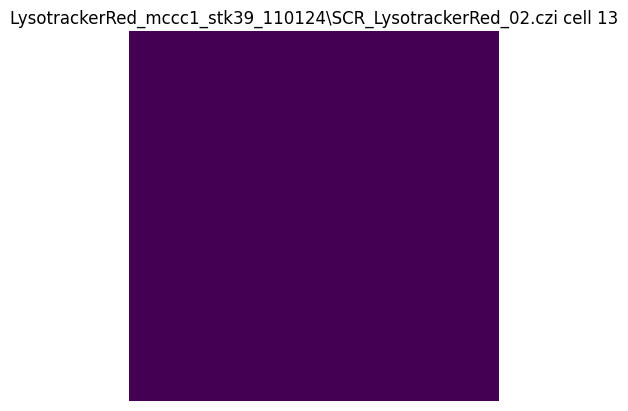

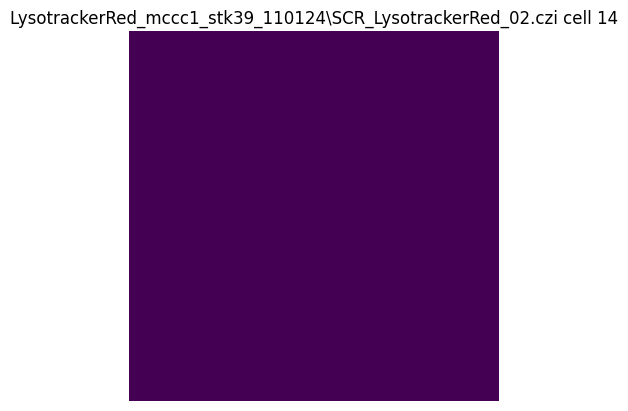

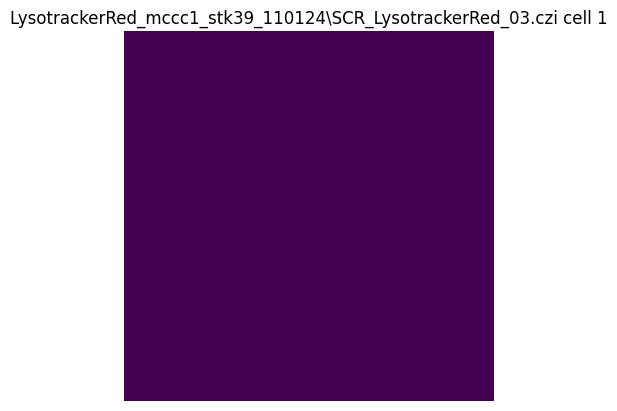

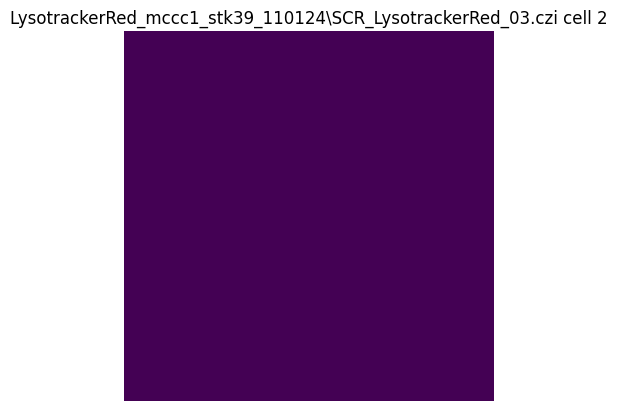

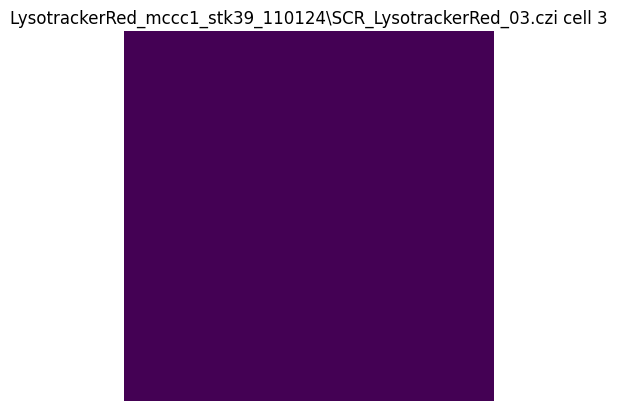

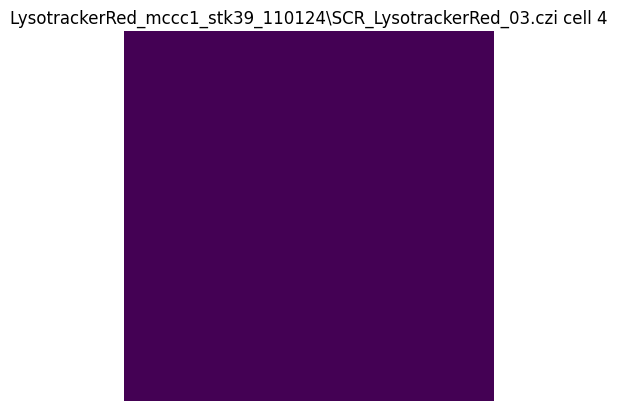

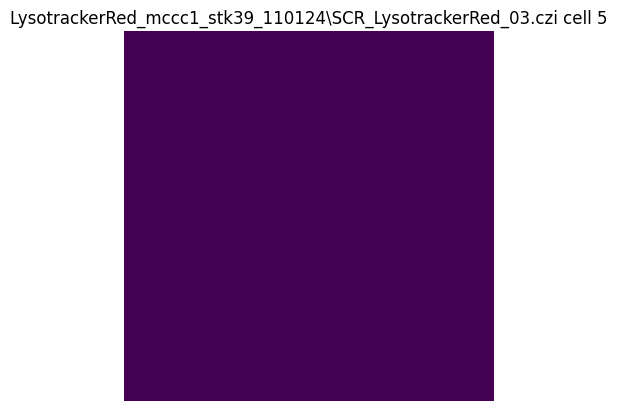

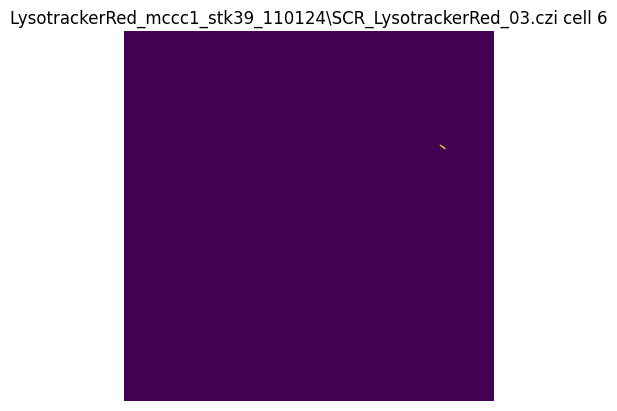

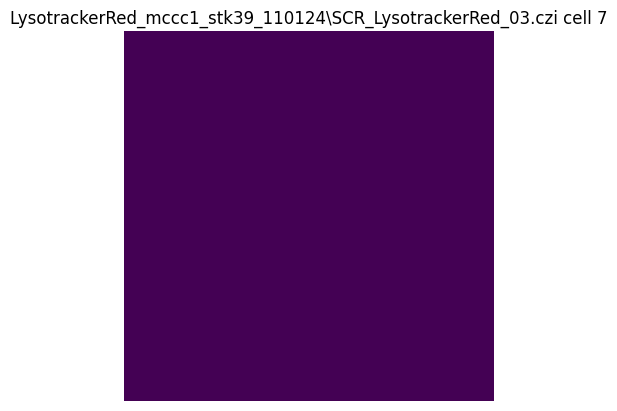

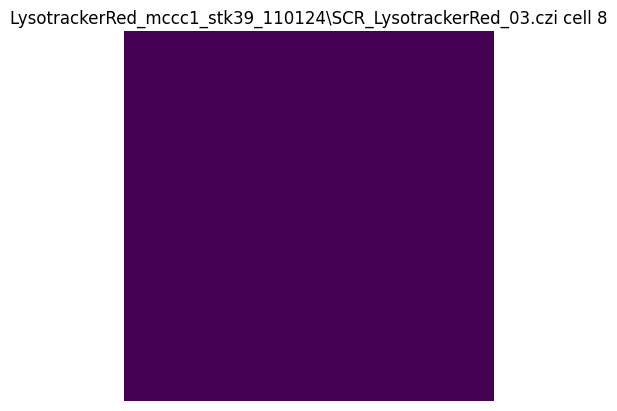

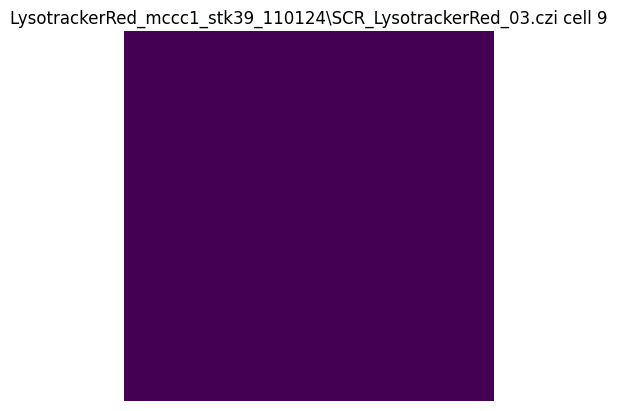

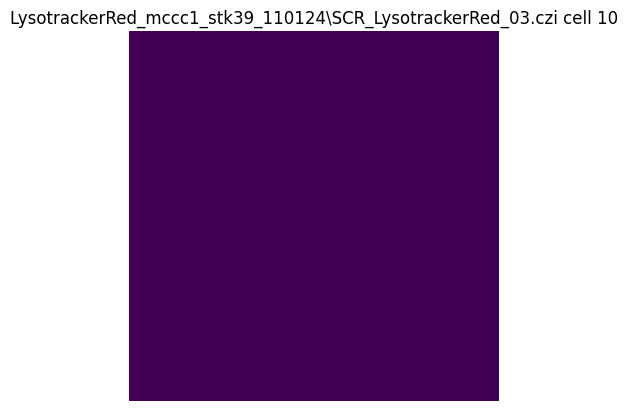

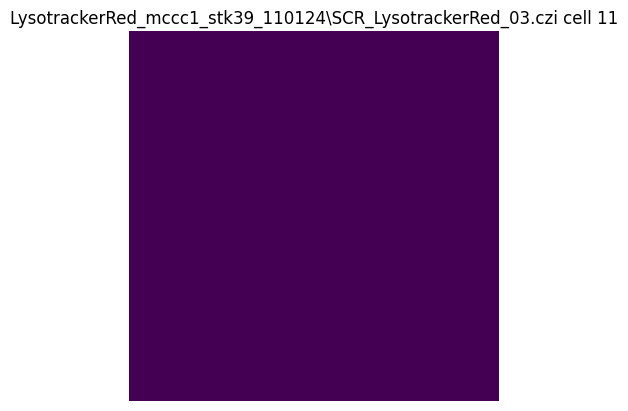

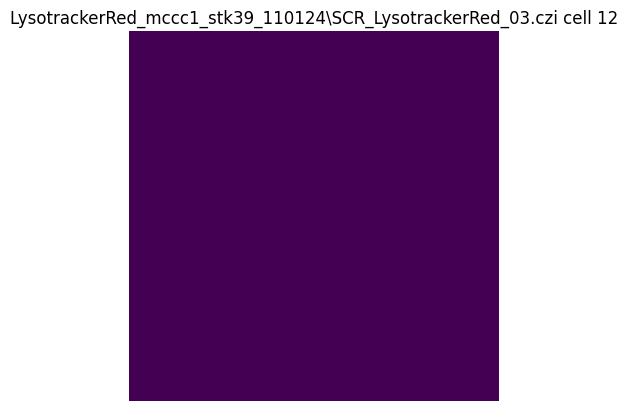

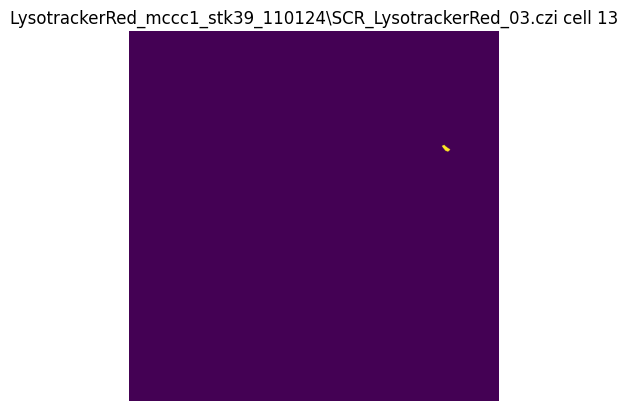

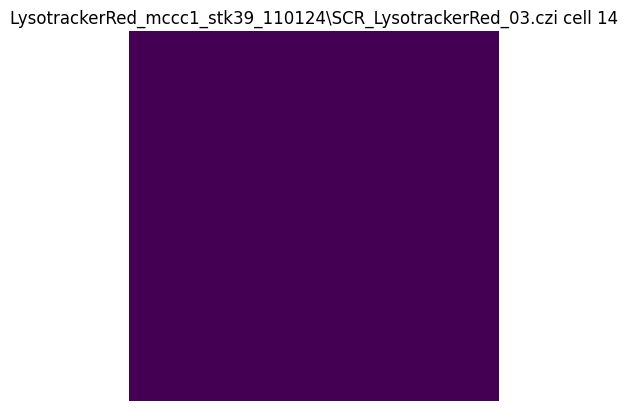

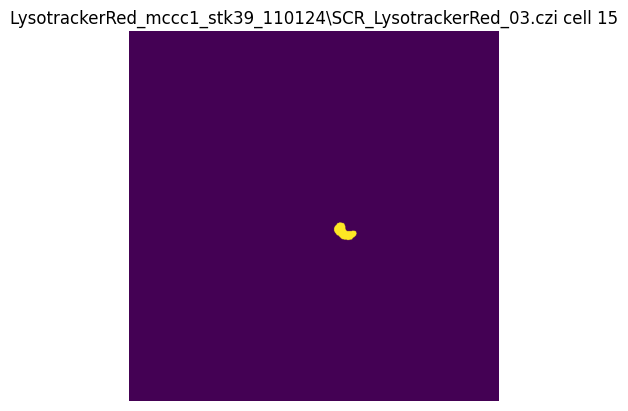

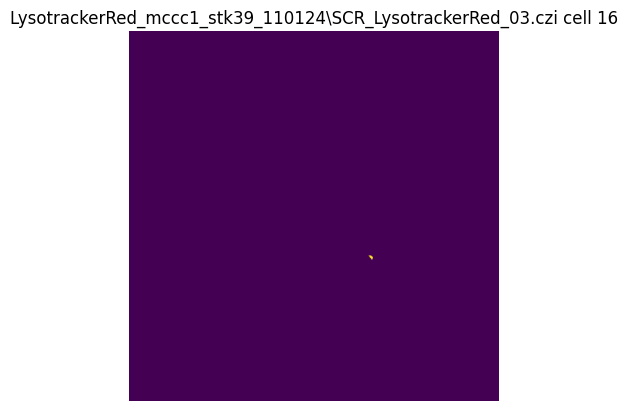

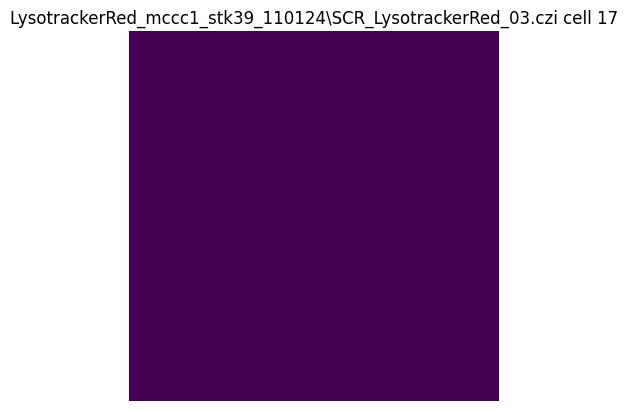

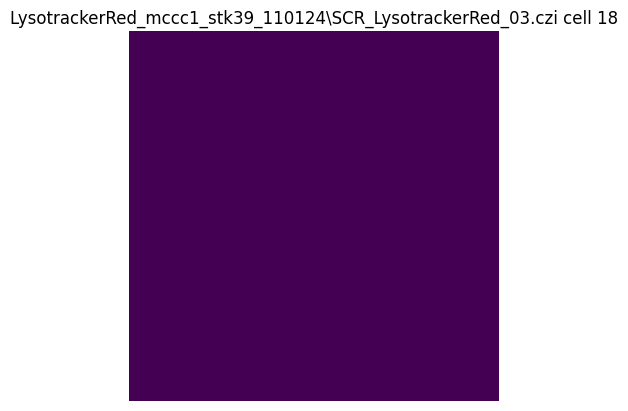

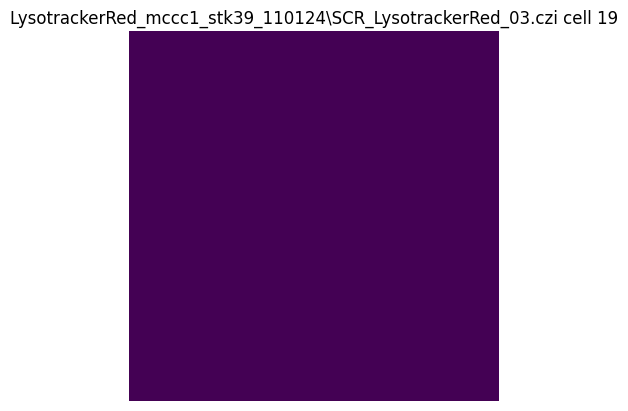

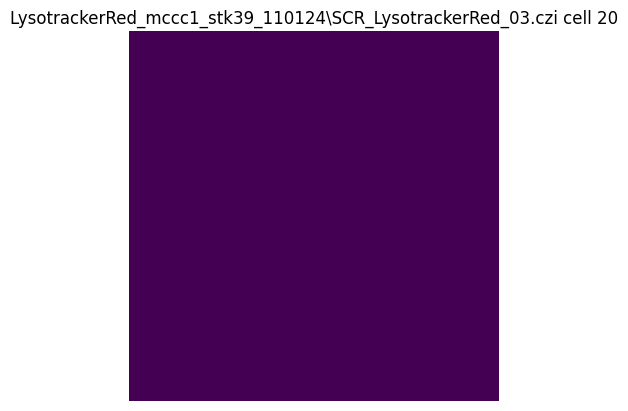

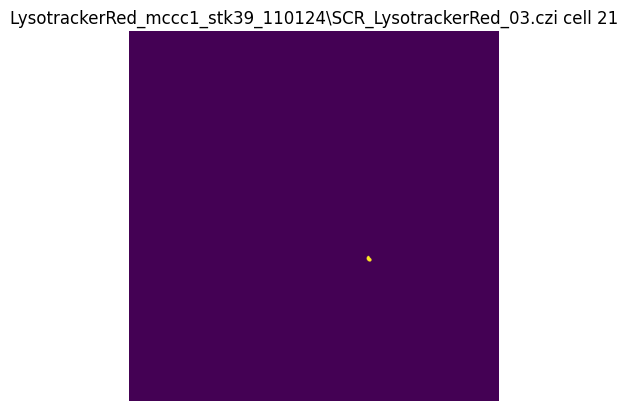

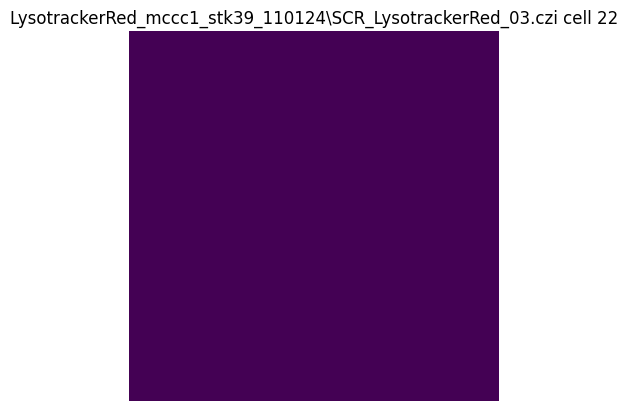

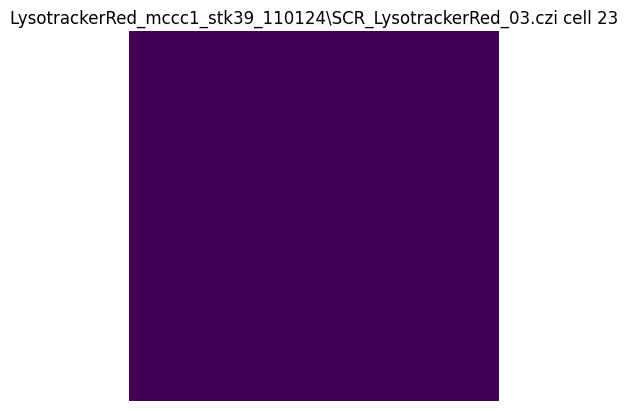

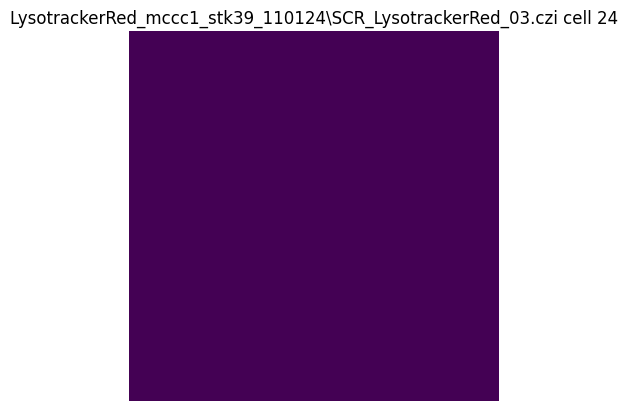

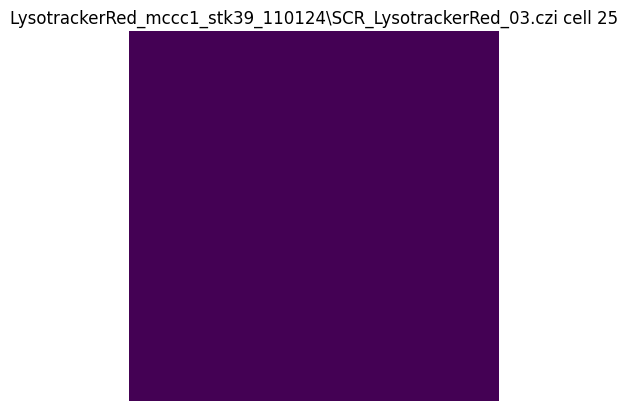

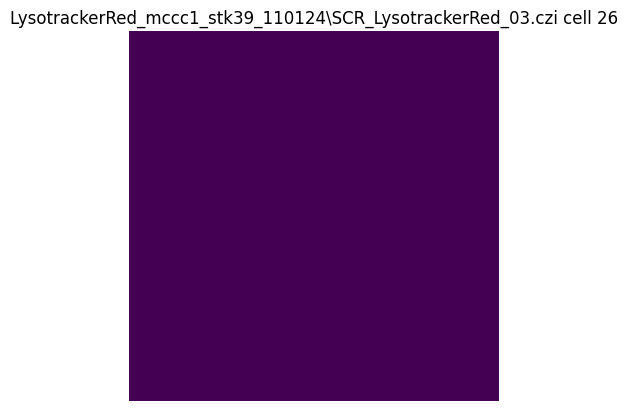

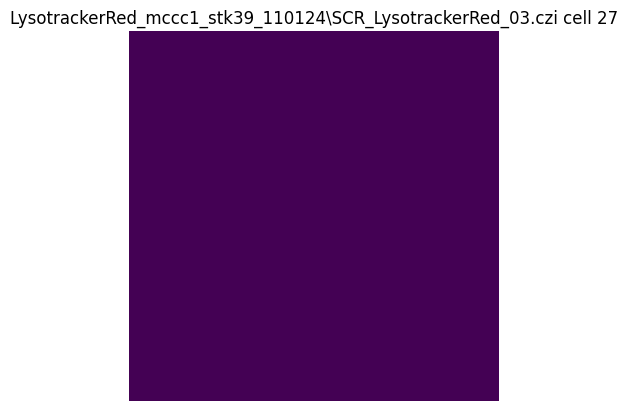

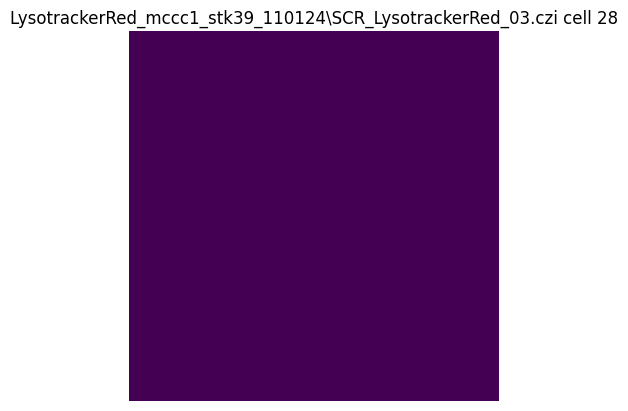

SystemError: CPUDispatcher(<function _extend_centers at 0x000001FE7C2D4C20>) returned a result with an exception set

In [156]:
def main(image_folder):
    # Initialize lists to store results
    surface_areas = []
    number_of_nuclei_list = []
    mean_sizes_of_inclusions = []
    sizes_df_new = None
    inclusions_size_list = []
    df_cell_summary_list = []
    output_dir = os.getcwd()

    images_to_analyze = extract_image_paths(image_folder)

    # Iterate over each image
    for path in images_to_analyze:
        image = read_image(path).squeeze()
        first_frame = image[1, :, :]
        target_shape = first_frame.shape 
        red_channel, dapi_channel, green_channel = extract_channels(image)

    
        # Process red channel for surface area
        #labeled_image_otsu = otsu_thresholding(red_channel, path)
        #surface_area = calculate_surface_area(labeled_image_otsu, red_channel)
        #surface_areas.append(surface_area)

        # Process green channel for inclusion quantification
        df_cell_summary = preprocess_red_green_channel(green_channel, red_channel, path)
        df_cell_summary_list.append(df_cell_summary)

            



        #labeled_image_inclusions = threshold_inclusions(confocal_img, path)
        #inclusion_sizes = measure_inclusion_sizes(labeled_image_inclusions, confocal_img)
        #mean_sizes_of_inclusions.append(np.mean(inclusion_sizes))

        # Add to DataFrame
        #sizes_df_new = add_to_dataframe(sizes_df_new, inclusion_sizes, os.path.basename(path))

        # Calculate metrics and save results
        # Combine all individual DataFrames

    combined_cell_summary_df = pd.concat(df_cell_summary_list, ignore_index=True)
    output_summary_path = os.path.join(output_dir, 'SUMMARY_CELLS_SUNGHOO_110124.xlsx')
    #SUMMARY_CELLS_SUNGHOO_110124.xlsx
    combined_cell_summary_df.to_excel(output_summary_path, index=False)

if __name__ == "__main__":
    image_folder = 'LysotrackerRed_mccc1_stk39_110124'
    main(image_folder)